In [1]:
################################################################################
#  MUMBAI HEAT STRESS CLASSIFICATION — Nambiar et al. (2026)
#  Station: 43003 (Santacruz) | Target: HI
#
#  PROPOSED: SAINT-XGB-Stack (SAINT × XGBoost × RF → LR meta-learner)
#  Optimized: 3-fold CV + smaller SAINT in stack for faster training
################################################################################
from google.colab import drive
drive.mount('/content/drive')

!pip install imbalanced-learn xgboost --quiet

import os, time, gc, warnings, math
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, cohen_kappa_score,
    multilabel_confusion_matrix
)
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import (
    EasyEnsembleClassifier, RUSBoostClassifier, BalancedBaggingClassifier
)
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Imports done')
print(f'TensorFlow : {tf.__version__}')
print(f'XGBoost    : {xgb.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
✅ Imports done
TensorFlow : 2.19.0
XGBoost    : 3.2.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# CELL 2 — Configuration
STATION_ID = '43003'
STATION    = 'Santacruz'
TARGET     = 'HI'

BASE_DIR   = '/content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7'
INPUT_DIR  = os.path.join(BASE_DIR, 'Class_balancing_output')
OUTPUT_DIR = os.path.join(BASE_DIR, '43003-HI-Model-final results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_COL = f'{TARGET}_Category'
TRAIN_END  = 2005
VAL_END    = 2015

FEATURES = ['DBT','WBT','VPD','VP','DPT','Temp_RH','FFF','Month_cos','Hour_cos','WBD']
PHYSICAL = ['DBT','WBT','VPD','VP','DPT','Temp_RH','FFF','WBD']
TEMPORAL = ['Month_cos','Hour_cos']

CLASS_NAMES = ['Low Risk','Moderate','High','Very High']
n_classes   = len(CLASS_NAMES)
EPOCHS      = 150
BATCH_SIZE  = 256
LR          = 1e-3

print(f'Station : {STATION} ({STATION_ID}) | Target: {TARGET}')
print(f'Classes : {CLASS_NAMES}')
print(f'Output  : {OUTPUT_DIR}')

Station : Santacruz (43003) | Target: HI
Classes : ['Low Risk', 'Moderate', 'High', 'Very High']
Output  : /content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43003-HI-Model-final results


In [3]:
# CELL 3 — Load Data + Feature Engineering + Temporal Split
fname = os.path.join(INPUT_DIR, f'{STATION_ID}_with_HI_PET_categories.csv')
df = pd.read_csv(fname)
print(f'Loaded {len(df):,} rows  |  Years: {df["YEAR"].min()}–{df["YEAR"].max()}')

df['sat_VP']    = 6.1121 * np.exp((18.678-df['DBT']/234.5)*(df['DBT']/(257.14+df['DBT'])))
df['VPD']       = (df['sat_VP'] - df['VP']).clip(lower=0)
df['Temp_RH']   = df['DBT'] * df['RH']
df['Month_cos'] = np.cos(2*np.pi*df['MN']/12)
df['HR_mapped'] = df['HR'].replace({24:0})
df['Hour_cos']  = np.cos(2*np.pi*df['HR_mapped']/24)
df['WBD']       = df['DBT'] - df['WBT']

train_raw = df[df['YEAR']<=TRAIN_END].copy()
val_raw   = df[(df['YEAR']>TRAIN_END)&(df['YEAR']<=VAL_END)].copy()
test_raw  = df[df['YEAR']>VAL_END].copy()

print(f'Train : {len(train_raw):>7,} | {dict(Counter(train_raw[TARGET_COL].astype(int)))}')
print(f'Val   : {len(val_raw):>7,} | {dict(Counter(val_raw[TARGET_COL].astype(int)))}')
print(f'Test  : {len(test_raw):>7,} | {dict(Counter(test_raw[TARGET_COL].astype(int)))}')

X_train_raw = train_raw[FEATURES].values
y_train_raw = train_raw[TARGET_COL].values.astype(int)
X_val       = val_raw[FEATURES].values
y_val       = val_raw[TARGET_COL].values.astype(int)
X_test      = test_raw[FEATURES].values
y_test      = test_raw[TARGET_COL].values.astype(int)

ALL_CLASSES = np.sort(np.unique(y_train_raw))
n_features  = len(FEATURES)
print(f'Classes: {ALL_CLASSES}  |  Features: {n_features}')

Loaded 155,390 rows  |  Years: 1969–2025
Train : 107,663 | {0: 76902, 1: 26857, 2: 3881, 3: 23}
Val   :  25,928 | {0: 16931, 1: 7422, 2: 1542, 3: 33}
Test  :  21,799 | {0: 13263, 1: 6506, 2: 2011, 3: 19}
Classes: [0 1 2 3]  |  Features: 10


In [4]:
# CELL 4 — SMOTE-ENN Balancing
print('Applying SMOTE-ENN ...')
smote_enn = SMOTEENN(smote=SMOTE(k_neighbors=3, random_state=SEED), random_state=SEED, n_jobs=-1)
X_phys = train_raw[PHYSICAL].values
X_phys_bal, y_train_bal = smote_enn.fit_resample(X_phys, y_train_raw)
nn_fit = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(X_phys)
_, idx = nn_fit.kneighbors(X_phys_bal)
X_temp_bal  = train_raw[TEMPORAL].values[idx.flatten()]
X_train_bal = np.hstack([X_phys_bal, X_temp_bal])
feat_order  = PHYSICAL + TEMPORAL
reorder_idx = [feat_order.index(f) for f in FEATURES]
X_train_bal = X_train_bal[:, reorder_idx]
print(f'Balanced train : {Counter(y_train_bal)}')
print(f'Shape: {X_train_bal.shape}')

Applying SMOTE-ENN ...
Balanced train : Counter({np.int64(3): 76902, np.int64(2): 76869, np.int64(1): 76437, np.int64(0): 76301})
Shape: (306509, 10)


In [5]:
# CELL 5 — Scaling + Class Weights
scaler_bal = StandardScaler().fit(X_train_bal)
X_tr_bal   = scaler_bal.transform(X_train_bal)
X_v_bal    = scaler_bal.transform(X_val)
X_te_bal   = scaler_bal.transform(X_test)

scaler_imb = StandardScaler().fit(X_train_raw)
X_tr_imb   = scaler_imb.transform(X_train_raw)
X_v_imb    = scaler_imb.transform(X_val)
X_te_imb   = scaler_imb.transform(X_test)

cw_arr  = compute_class_weight('balanced', classes=ALL_CLASSES, y=y_train_raw)
CW_DICT = dict(zip(ALL_CLASSES, cw_arr))

y_tr_bal_idx = np.searchsorted(ALL_CLASSES, y_train_bal)
y_tr_imb_idx = np.searchsorted(ALL_CLASSES, y_train_raw)
y_v_idx      = np.searchsorted(ALL_CLASSES, y_val)
y_te_idx     = np.searchsorted(ALL_CLASSES, y_test)

print(f'Class weights: {CW_DICT}')

Class weights: {np.int64(0): np.float64(0.3500006501781488), np.int64(1): np.float64(1.0021875116357002), np.int64(2): np.float64(6.935261530533368), np.int64(3): np.float64(1170.25)}


In [6]:
# CELL 6 — Evaluation Utilities
ALL_RESULTS = []

def evaluate_model(name, y_true, y_pred, y_proba, split, training_type, train_time=0):
    m = {'Model':name,'Split':split,'Training_Type':training_type,
         'Accuracy':round(accuracy_score(y_true,y_pred),4),
         'F1_macro':round(f1_score(y_true,y_pred,average='macro',zero_division=0),4),
         'F1_weighted':round(f1_score(y_true,y_pred,average='weighted',zero_division=0),4),
         'Precision':round(precision_score(y_true,y_pred,average='macro',zero_division=0),4),
         'Recall':round(recall_score(y_true,y_pred,average='macro',zero_division=0),4),
         'Kappa':round(cohen_kappa_score(y_true,y_pred),4),
         'Train_Time_s':round(train_time,1)}
    if y_proba is not None:
        try: m['ROC_AUC']=round(roc_auc_score(y_true,y_proba,multi_class='ovr',average='weighted'),4)
        except: m['ROC_AUC']=np.nan
    ALL_RESULTS.append(m); return m

def full_evaluate(name,y_tr,y_tr_pred,y_v,y_v_pred,y_v_proba,y_te,y_te_pred,y_te_proba,tt,training_type,print_tptn=False):
    evaluate_model(name,y_tr,y_tr_pred,None,'Train',training_type,tt)
    evaluate_model(name,y_v,y_v_pred,y_v_proba,'Validation',training_type,tt)
    m=evaluate_model(name,y_te,y_te_pred,y_te_proba,'Test',training_type,tt)
    print(f'\n{"="*70}\n  {name} ({training_type}) — Test\n{"="*70}')
    print(f'  Acc={m["Accuracy"]:.4f}  F1={m["F1_macro"]:.4f}  Kappa={m["Kappa"]:.4f}  ROC={m.get("ROC_AUC","N/A")}')
    print(classification_report(y_te,y_te_pred,target_names=CLASS_NAMES,zero_division=0))
    if print_tptn:
        mcm=multilabel_confusion_matrix(y_te,y_te_pred)
        print(f'  {"Class":<18} {"TP":>7} {"TN":>8} {"FP":>7} {"FN":>7} {"Sensitivity":>13} {"Specificity":>13}')
        print(f'  {"-"*76}')
        for i,cls in enumerate(CLASS_NAMES):
            tn,fp,fn,tp=mcm[i].ravel()
            sens=tp/(tp+fn) if (tp+fn)>0 else 0.; spec=tn/(tn+fp) if (tn+fp)>0 else 0.
            print(f'  {cls:<18} {int(tp):>7} {int(tn):>8} {int(fp):>7} {int(fn):>7} {sens:>13.4f} {spec:>13.4f}')
    return m

def plot_confusion(y_true,y_pred,title):
    cm=confusion_matrix(y_true,y_pred)
    fig,ax=plt.subplots(figsize=(7,6))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax)
    ax.set_title(f'CM — {title}',fontsize=11); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_cm_{title}.png'),dpi=150,bbox_inches='tight')
    plt.show(); plt.close()

print('✅ Evaluation utilities ready.')

✅ Evaluation utilities ready.


In [7]:
# CELL 7 — Training Utilities
def get_dl_callbacks(name, patience=20):
    return [
        callbacks.EarlyStopping(monitor='val_loss',patience=patience,restore_best_weights=True,verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=8,min_lr=1e-7,verbose=0),
    ]

def plot_dl_history(hist, title):
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    axes[0].plot(hist.history['loss'],label='Train'); axes[0].plot(hist.history['val_loss'],label='Val')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].plot(hist.history['accuracy'],label='Train'); axes[1].plot(hist.history['val_accuracy'],label='Val')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_hist_{title}.png'),dpi=150,bbox_inches='tight')
    plt.show(); plt.close()

def train_dl(model, name, X_tr, y_tr_idx, X_v, y_v_true,
             X_te, y_te_orig, training_type,
             use_cw=True, patience=20):
    y_v_idx_local = np.searchsorted(ALL_CLASSES, y_v_true)
    print(f'\n{"─"*50}\nTraining {name} ({training_type})...')
    t0 = time.time()
    hist = model.fit(
        X_tr, y_tr_idx,
        validation_data=(X_v, y_v_idx_local),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        class_weight=CW_DICT if use_cw else None,
        callbacks=get_dl_callbacks(name, patience=patience),
        verbose=0
    )
    tt = time.time() - t0
    plot_dl_history(hist, f'{name}_{training_type}')

    cls_arr    = np.array(ALL_CLASSES)
    y_tr_pred  = model.predict(X_tr, verbose=0).argmax(1)
    y_v_pred   = model.predict(X_v,  verbose=0).argmax(1)
    y_te_proba = model.predict(X_te, verbose=0)
    y_te_pred  = y_te_proba.argmax(1)
    y_v_proba  = model.predict(X_v,  verbose=0)
    y_tr_true  = cls_arr[y_tr_idx]

    full_evaluate(name,
                  y_tr_true,          cls_arr[y_tr_pred],
                  y_v_true,           cls_arr[y_v_pred],  y_v_proba,
                  y_te_orig,          cls_arr[y_te_pred], y_te_proba,
                  tt, training_type)
    plot_confusion(y_te_orig, cls_arr[y_te_pred], f'{name}_{training_type}')
    try:
        model.save(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_{name}_{training_type}.keras'))
    except: pass
    gc.collect()
    return model, hist

def train_sklearn(model,name,X_tr,y_tr,X_v,y_v,X_te,y_te,training_type):
    print(f'\n{"─"*50}\nTraining {name} ({training_type})...')
    t0=time.time(); model.fit(X_tr,y_tr); tt=time.time()-t0
    y_tr_pred=model.predict(X_tr); y_v_pred=model.predict(X_v); y_te_pred=model.predict(X_te)
    y_v_proba=model.predict_proba(X_v) if hasattr(model,'predict_proba') else None
    y_te_proba=model.predict_proba(X_te) if hasattr(model,'predict_proba') else None
    full_evaluate(name,y_tr,y_tr_pred,y_v,y_v_pred,y_v_proba,y_te,y_te_pred,y_te_proba,tt,training_type)
    plot_confusion(y_te,y_te_pred,f'{name}_{training_type}')
    return model

print('✅ Training utilities ready.')

✅ Training utilities ready.


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — SAINT Architecture                                              ║
# ║  Somepalli et al. (2021) "SAINT: Improved Neural Networks for Tabular     ║
# ║  Data via Row Attention and Contrastive Pre-Training"                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class IntersampleAttentionLayer(layers.Layer):
    def __init__(self, n_heads, d_model, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.drop = layers.Dropout(dropout)

    def call(self, x, training=None):
        xt = tf.transpose(x, perm=[1, 0, 2])
        attn_out = self.mha(xt, xt, training=training)
        attn_out = self.drop(attn_out, training=training)
        xt = self.norm(xt + attn_out)
        return tf.transpose(xt, perm=[1, 0, 2])

class SAINTEncoderBlock(layers.Layer):
    def __init__(self, n_heads, d_model, ffn_mult=4, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.col_norm = layers.LayerNormalization(epsilon=1e-6)
        self.col_mha  = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.col_drop = layers.Dropout(dropout)
        self.row_attn = IntersampleAttentionLayer(n_heads, d_model, dropout)
        self.ffn_norm = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = keras.Sequential([
            layers.Dense(d_model*ffn_mult, activation='gelu', kernel_regularizer=regularizers.l2(1e-5)),
            layers.Dropout(dropout),
            layers.Dense(d_model, kernel_regularizer=regularizers.l2(1e-5)),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=None):
        x_norm = self.col_norm(x)
        attn = self.col_mha(x_norm, x_norm, training=training)
        attn = self.col_drop(attn, training=training)
        x = x + attn
        x = self.row_attn(x, training=training)
        x_norm = self.ffn_norm(x)
        x = x + self.ffn(x_norm, training=training)
        return x

def build_saint(n_features, n_classes, d_token=64, n_heads=8, n_layers=3,
                ffn_mult=4, dropout=0.1, seed=42, name='SAINT'):
    tf.random.set_seed(seed)
    inp = layers.Input(shape=(n_features,), name='input')
    token_list = []
    for j in range(n_features):
        f_j = layers.Lambda(lambda x, i=j: x[:, i:i+1])(inp)
        t_j = layers.Dense(d_token, use_bias=True, kernel_regularizer=regularizers.l2(1e-5))(f_j)
        token_list.append(layers.Reshape((1, d_token))(t_j))
    feature_tokens = layers.Concatenate(axis=1)(token_list)
    cls_token = tf.Variable(tf.zeros((1, 1, d_token)), trainable=True, name='cls_token')
    cls_tiled = layers.Lambda(lambda x: tf.tile(cls_token, [tf.shape(x)[0], 1, 1]))(feature_tokens)
    tokens = layers.Concatenate(axis=1)([cls_tiled, feature_tokens])
    x = tokens
    for layer_idx in range(n_layers):
        x = SAINTEncoderBlock(n_heads=n_heads, d_model=d_token, ffn_mult=ffn_mult,
                              dropout=dropout, name=f'saint_block_{layer_idx}')(x)
    cls_out = layers.Lambda(lambda x: x[:, 0, :])(x)
    cls_out = layers.LayerNormalization(epsilon=1e-6)(cls_out)
    logits  = layers.Dense(n_classes, activation='softmax', dtype='float32', name='output')(cls_out)
    m = Model(inp, logits, name=name)
    m.compile(optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

print('✅ SAINT architecture defined.')
_test = build_saint(n_features, n_classes)
_test.summary()
del _test; gc.collect()

✅ SAINT architecture defined.


Model: "SAINT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        128 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        128 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        128 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        128 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        128 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │        128 │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        128 │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │        128 │ lambda_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        128 │ lambda_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │        128 │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 64)     │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 64)     │          0 │ dense_3[0][0]   

 Total params: 201,924 (788.77 KB)

 Trainable params: 201,924 (788.77 KB)

 Non-trainable params: 0 (0.00 B)

18321


──────────────────────────────────────────────────
Training KNN (Balanced)...

  KNN (Balanced) — Test
  Acc=0.9381  F1=0.7473  Kappa=0.8839  ROC=0.9697
              precision    recall  f1-score   support

    Low Risk       0.97      0.97      0.97     13263
    Moderate       0.89      0.91      0.90      6506
        High       0.89      0.82      0.85      2011
   Very High       0.16      0.84      0.26        19

    accuracy                           0.94     21799
   macro avg       0.73      0.89      0.75     21799
weighted avg       0.94      0.94      0.94     21799



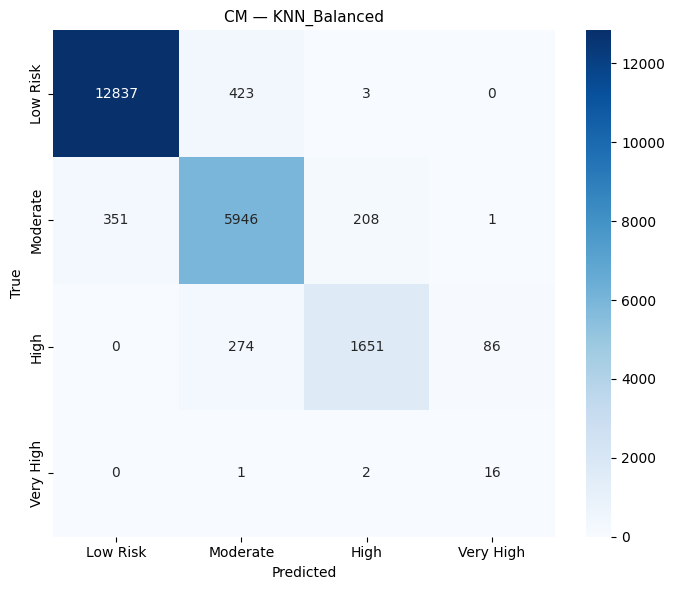


──────────────────────────────────────────────────
Training KNN (Imbalanced)...

  KNN (Imbalanced) — Test
  Acc=0.9543  F1=0.7156  Kappa=0.9128  ROC=0.9904
              precision    recall  f1-score   support

    Low Risk       0.97      0.99      0.98     13263
    Moderate       0.91      0.94      0.93      6506
        High       0.97      0.77      0.85      2011
   Very High       1.00      0.05      0.10        19

    accuracy                           0.95     21799
   macro avg       0.96      0.69      0.72     21799
weighted avg       0.95      0.95      0.95     21799



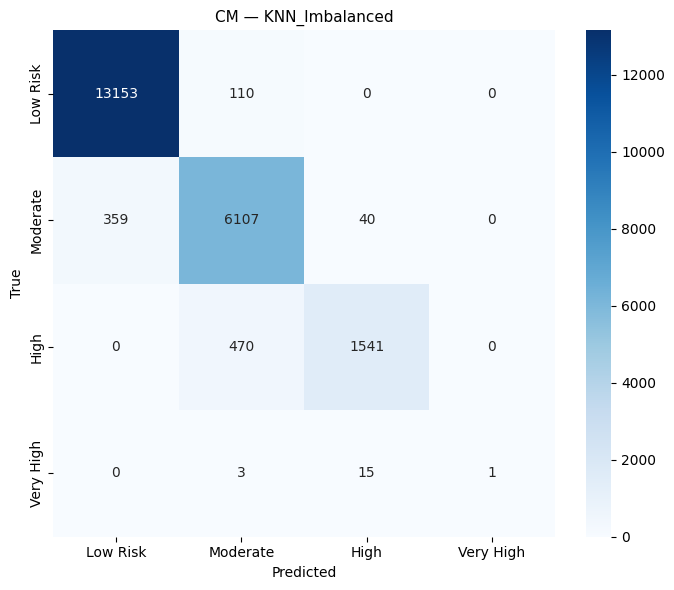


──────────────────────────────────────────────────
Training SVC (Balanced)...

  SVC (Balanced) — Test
  Acc=0.9712  F1=0.8043  Kappa=0.9462  ROC=0.999
              precision    recall  f1-score   support

    Low Risk       0.99      0.98      0.99     13263
    Moderate       0.95      0.96      0.96      6506
        High       0.94      0.94      0.94      2011
   Very High       0.21      0.89      0.34        19

    accuracy                           0.97     21799
   macro avg       0.77      0.94      0.80     21799
weighted avg       0.97      0.97      0.97     21799



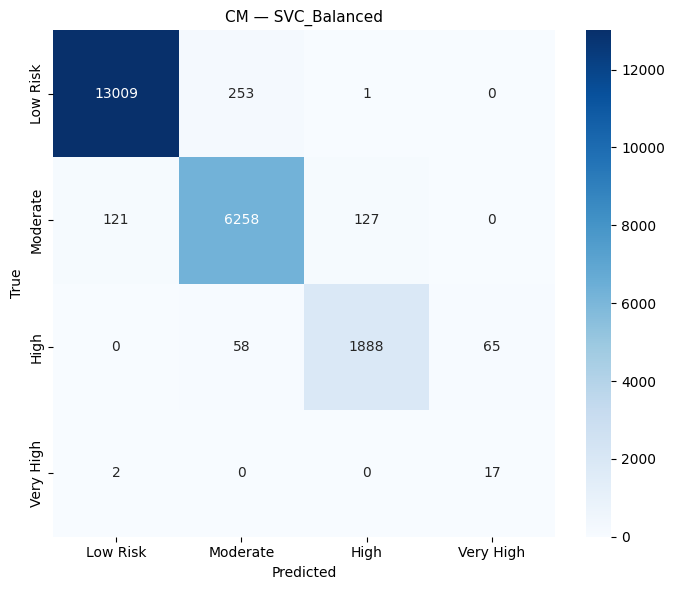


──────────────────────────────────────────────────
Training SVC (Imbalanced)...

  SVC (Imbalanced) — Test
  Acc=0.9703  F1=0.8632  Kappa=0.9447  ROC=0.9993
              precision    recall  f1-score   support

    Low Risk       0.99      0.97      0.98     13263
    Moderate       0.94      0.96      0.95      6506
        High       0.91      0.98      0.95      2011
   Very High       0.52      0.63      0.57        19

    accuracy                           0.97     21799
   macro avg       0.84      0.89      0.86     21799
weighted avg       0.97      0.97      0.97     21799



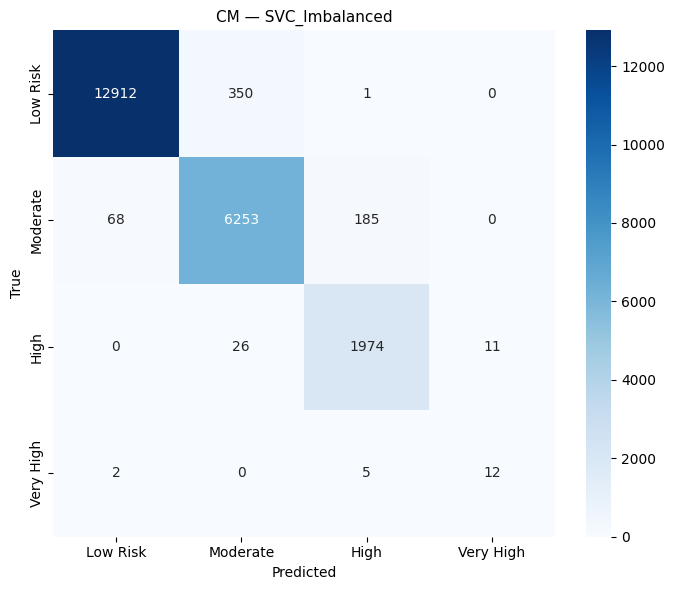


──────────────────────────────────────────────────
Training NaiveBayes (Balanced)...

  NaiveBayes (Balanced) — Test
  Acc=0.7257  F1=0.5383  Kappa=0.5291  ROC=0.8939
              precision    recall  f1-score   support

    Low Risk       0.93      0.74      0.82     13263
    Moderate       0.55      0.68      0.61      6506
        High       0.60      0.75      0.67      2011
   Very High       0.03      0.84      0.05        19

    accuracy                           0.73     21799
   macro avg       0.53      0.75      0.54     21799
weighted avg       0.78      0.73      0.75     21799



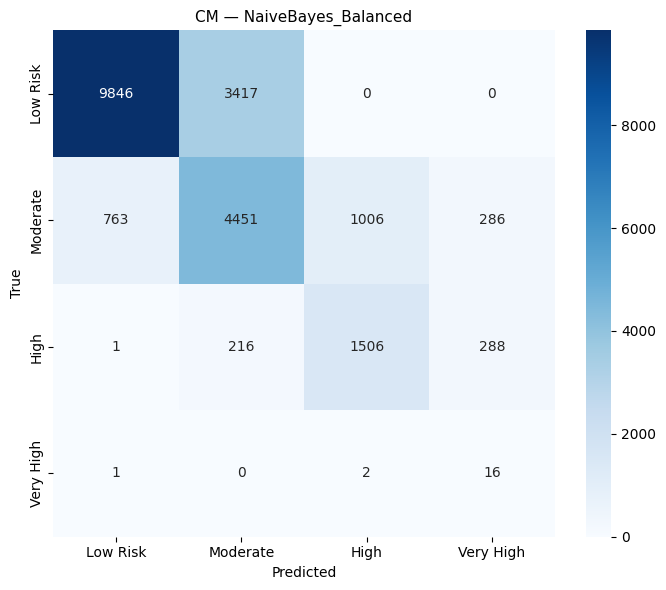


──────────────────────────────────────────────────
Training NaiveBayes (Imbalanced)...

  NaiveBayes (Imbalanced) — Test
  Acc=0.7722  F1=0.6168  Kappa=0.5890  ROC=0.8987
              precision    recall  f1-score   support

    Low Risk       0.90      0.79      0.84     13263
    Moderate       0.60      0.76      0.67      6506
        High       0.76      0.72      0.74      2011
   Very High       0.16      0.37      0.22        19

    accuracy                           0.77     21799
   macro avg       0.60      0.66      0.62     21799
weighted avg       0.80      0.77      0.78     21799



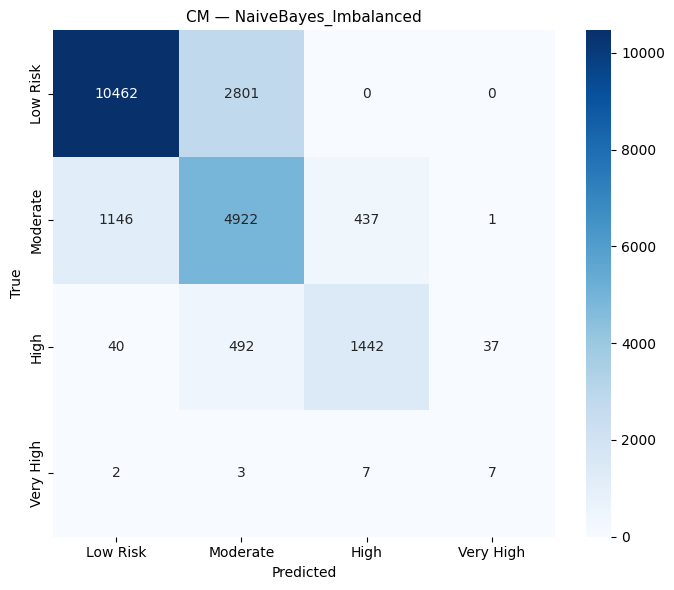


──────────────────────────────────────────────────
Training AdaBoost (Balanced)...

  AdaBoost (Balanced) — Test
  Acc=0.8562  F1=0.7207  Kappa=0.7416  ROC=0.8563
              precision    recall  f1-score   support

    Low Risk       0.97      0.85      0.91     13263
    Moderate       0.70      0.90      0.79      6506
        High       0.82      0.77      0.80      2011
   Very High       0.27      0.68      0.39        19

    accuracy                           0.86     21799
   macro avg       0.69      0.80      0.72     21799
weighted avg       0.88      0.86      0.86     21799



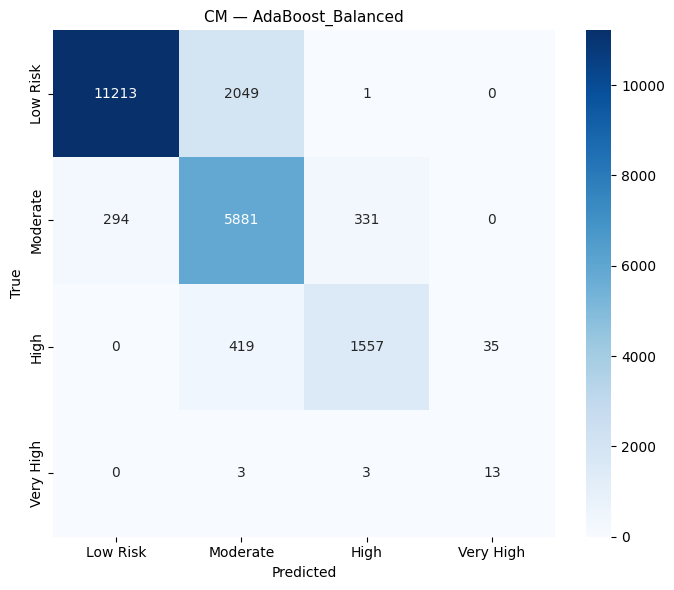


──────────────────────────────────────────────────
Training AdaBoost (Imbalanced)...

  AdaBoost (Imbalanced) — Test
  Acc=0.8959  F1=0.6407  Kappa=0.8063  ROC=0.9315
              precision    recall  f1-score   support

    Low Risk       0.97      0.91      0.94     13263
    Moderate       0.76      0.95      0.85      6506
        High       0.98      0.64      0.78      2011
   Very High       0.00      0.00      0.00        19

    accuracy                           0.90     21799
   macro avg       0.68      0.63      0.64     21799
weighted avg       0.91      0.90      0.90     21799



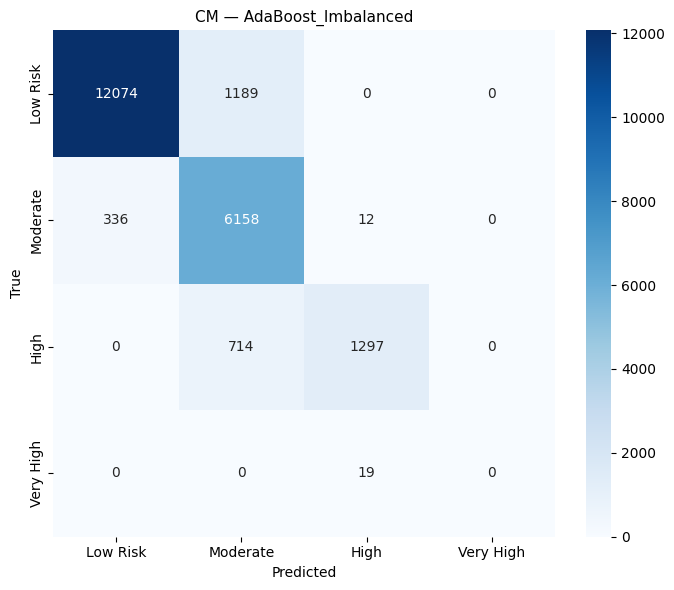


──────────────────────────────────────────────────
Training LDA (Balanced)...

  LDA (Balanced) — Test
  Acc=0.7795  F1=0.6492  Kappa=0.6269  ROC=0.9591
              precision    recall  f1-score   support

    Low Risk       1.00      0.72      0.84     13263
    Moderate       0.59      0.87      0.71      6506
        High       0.67      0.86      0.75      2011
   Very High       0.18      0.84      0.30        19

    accuracy                           0.78     21799
   macro avg       0.61      0.82      0.65     21799
weighted avg       0.85      0.78      0.79     21799



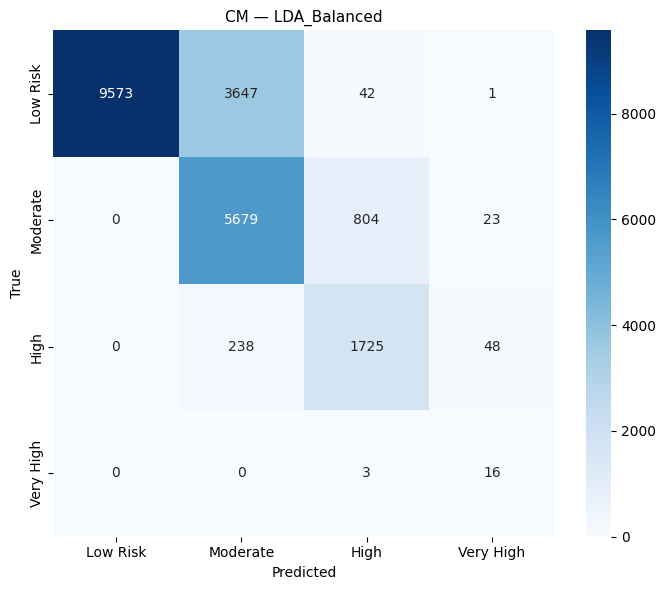


──────────────────────────────────────────────────
Training LDA (Imbalanced)...

  LDA (Imbalanced) — Test
  Acc=0.8498  F1=0.5908  Kappa=0.7202  ROC=0.9346
              precision    recall  f1-score   support

    Low Risk       0.94      0.96      0.95     13263
    Moderate       0.84      0.70      0.76      6506
        High       0.70      0.58      0.64      2011
   Very High       0.01      0.37      0.01        19

    accuracy                           0.85     21799
   macro avg       0.62      0.65      0.59     21799
weighted avg       0.88      0.85      0.86     21799



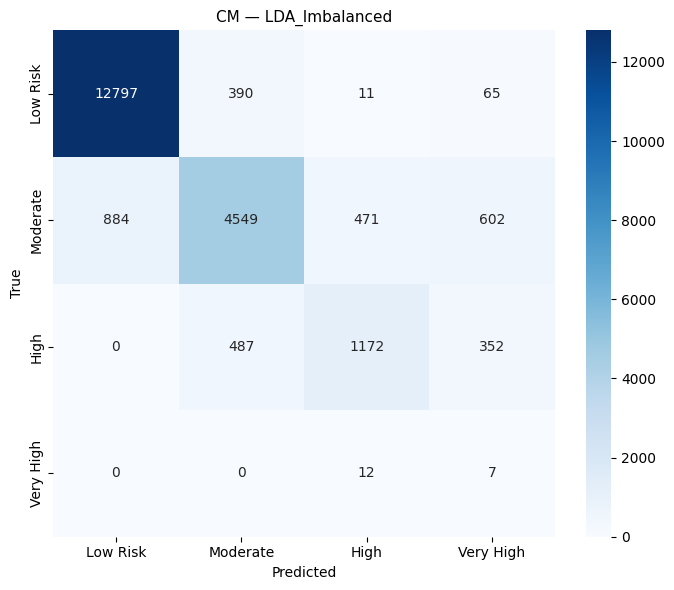


──────────────────────────────────────────────────
Training EasyEnsemble (Imbalanced)...

  EasyEnsemble (Imbalanced) — Test
  Acc=0.4154  F1=0.3799  Kappa=0.1608  ROC=0.7913
              precision    recall  f1-score   support

    Low Risk       0.92      0.16      0.27     13263
    Moderate       0.32      0.83      0.46      6506
        High       0.73      0.77      0.75      2011
   Very High       0.02      0.58      0.04        19

    accuracy                           0.42     21799
   macro avg       0.50      0.58      0.38     21799
weighted avg       0.72      0.42      0.37     21799



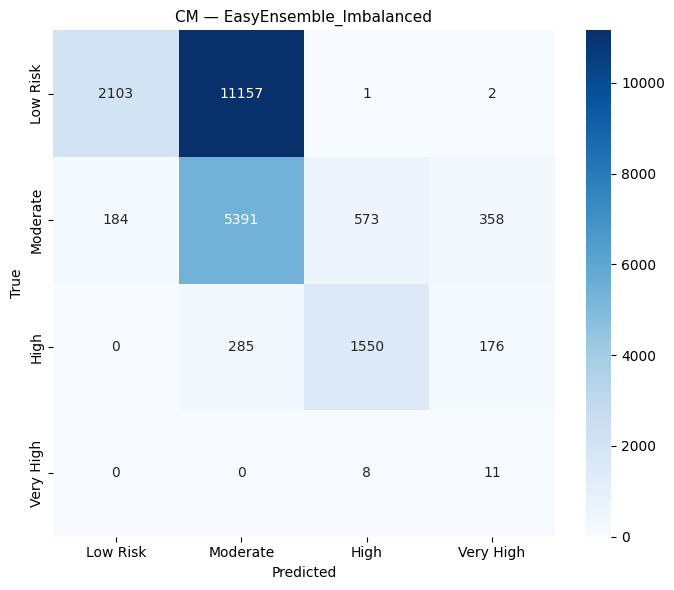


──────────────────────────────────────────────────
Training RUSBoost (Imbalanced)...

  RUSBoost (Imbalanced) — Test
  Acc=0.5349  F1=0.4424  Kappa=0.2875  ROC=0.7756
              precision    recall  f1-score   support

    Low Risk       0.96      0.32      0.48     13263
    Moderate       0.39      0.97      0.56      6506
        High       0.95      0.55      0.70      2011
   Very High       0.02      0.21      0.03        19

    accuracy                           0.53     21799
   macro avg       0.58      0.51      0.44     21799
weighted avg       0.79      0.53      0.52     21799



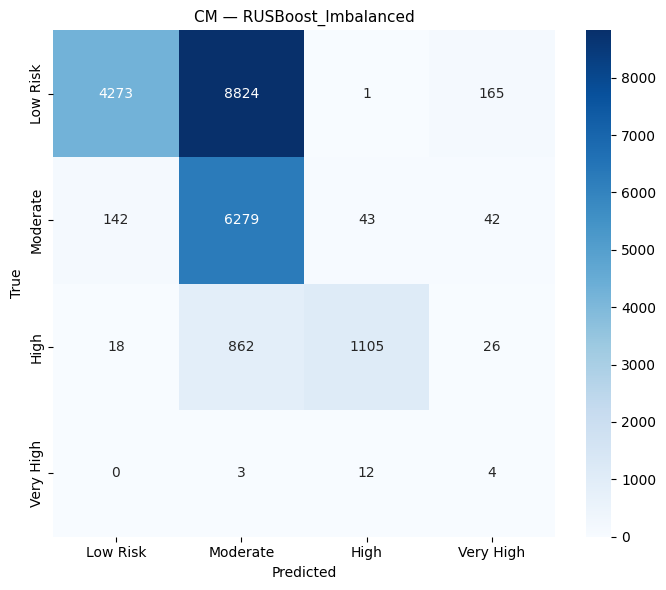


──────────────────────────────────────────────────
Training BBAG (Imbalanced)...

  BBAG (Imbalanced) — Test
  Acc=0.9008  F1=0.7234  Kappa=0.8149  ROC=0.983
              precision    recall  f1-score   support

    Low Risk       0.95      0.93      0.94     13263
    Moderate       0.82      0.87      0.85      6506
        High       0.87      0.79      0.83      2011
   Very High       0.16      0.84      0.28        19

    accuracy                           0.90     21799
   macro avg       0.70      0.86      0.72     21799
weighted avg       0.91      0.90      0.90     21799



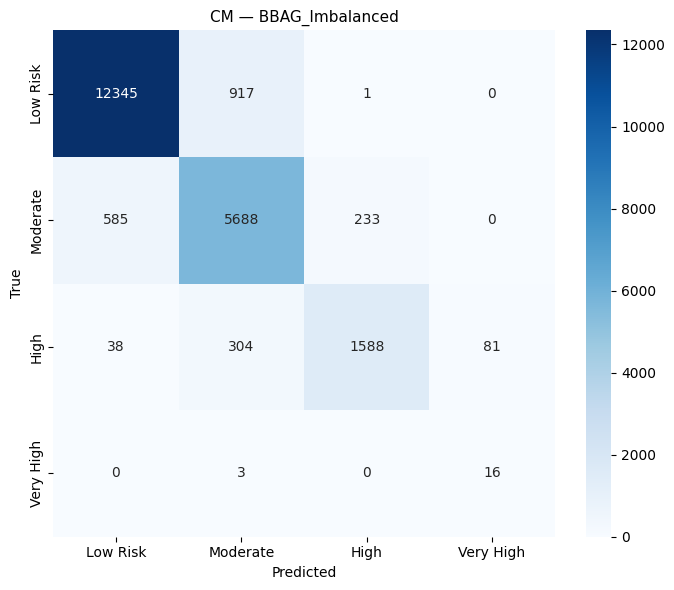

BalancedBaggingClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
# CELL 9 — Sklearn Baselines (RandomForest excluded — used inside Stack only)
train_sklearn(KNeighborsClassifier(n_neighbors=5,n_jobs=-1),'KNN',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(KNeighborsClassifier(n_neighbors=5,n_jobs=-1),'KNN',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(SVC(kernel='rbf',probability=True,random_state=SEED),'SVC',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(SVC(kernel='rbf',probability=True,class_weight='balanced',random_state=SEED),'SVC',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(GaussianNB(),'NaiveBayes',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(GaussianNB(),'NaiveBayes',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(AdaBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'AdaBoost',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(AdaBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'AdaBoost',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(LinearDiscriminantAnalysis(),'LDA',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(LinearDiscriminantAnalysis(),'LDA',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(EasyEnsembleClassifier(n_estimators=10,random_state=SEED,n_jobs=-1),'EasyEnsemble',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(RUSBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'RUSBoost',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(BalancedBaggingClassifier(n_estimators=50,random_state=SEED,n_jobs=-1),'BBAG',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')


═══ Training SAINT baseline (Balanced) ═══

──────────────────────────────────────────────────
Training SAINT (Balanced)...


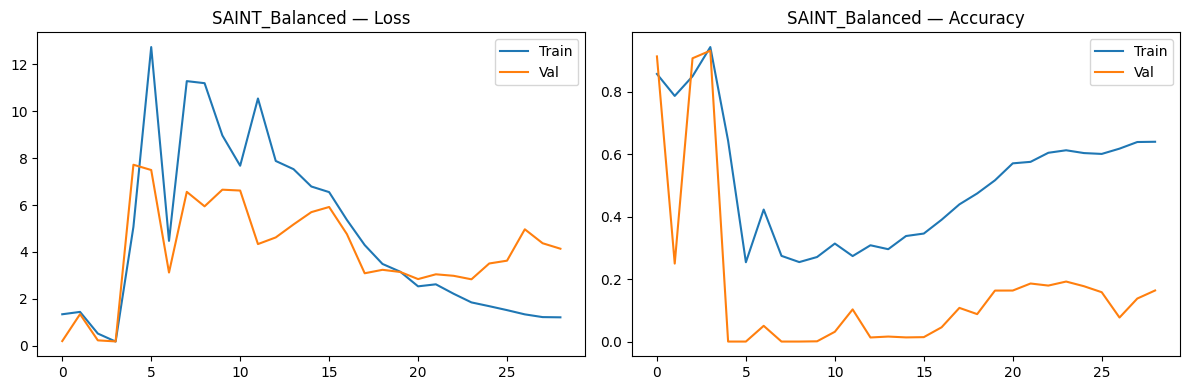


  SAINT (Balanced) — Test
  Acc=0.8980  F1=0.6789  Kappa=0.8072  ROC=0.9743
              precision    recall  f1-score   support

    Low Risk       0.93      0.98      0.95     13263
    Moderate       0.93      0.74      0.83      6506
        High       0.76      0.89      0.82      2011
   Very High       0.06      0.95      0.12        19

    accuracy                           0.90     21799
   macro avg       0.67      0.89      0.68     21799
weighted avg       0.91      0.90      0.90     21799



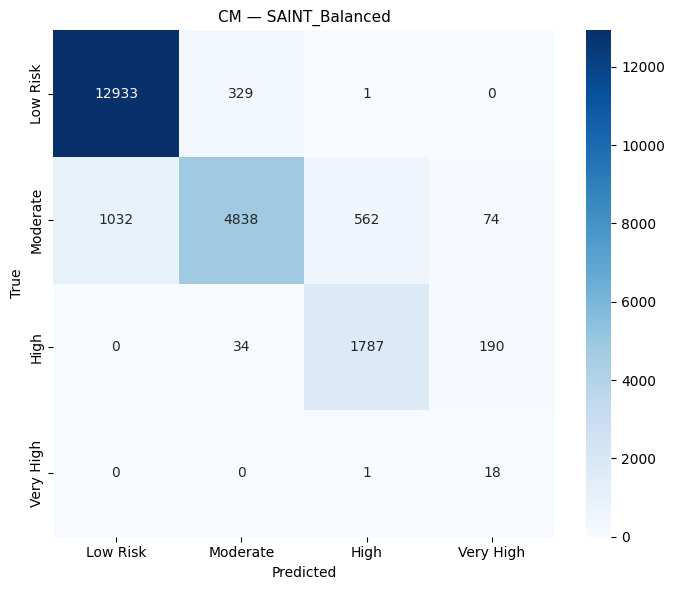


═══ Training SAINT baseline (Imbalanced) ═══

──────────────────────────────────────────────────
Training SAINT (Imbalanced)...


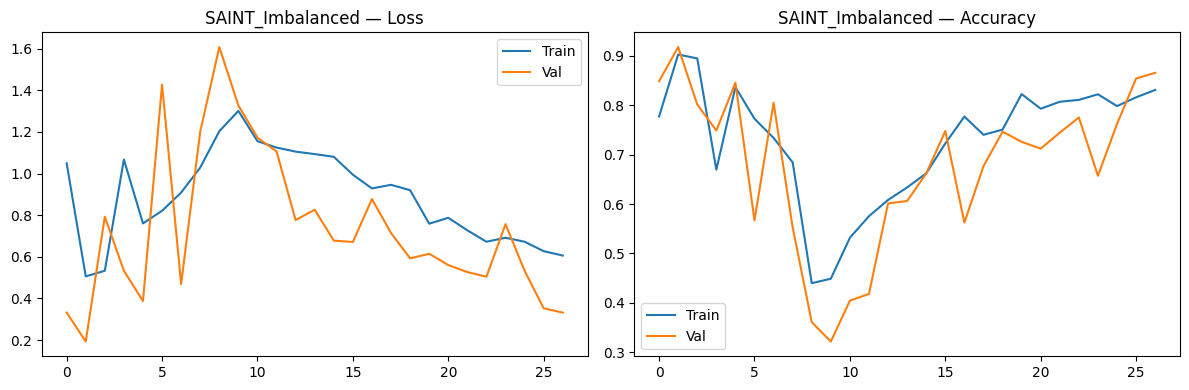


  SAINT (Imbalanced) — Test
  Acc=0.8610  F1=0.6096  Kappa=0.7501  ROC=0.9775
              precision    recall  f1-score   support

    Low Risk       0.98      0.92      0.95     13263
    Moderate       0.83      0.79      0.81      6506
        High       0.59      0.68      0.63      2011
   Very High       0.02      1.00      0.05        19

    accuracy                           0.86     21799
   macro avg       0.60      0.85      0.61     21799
weighted avg       0.90      0.86      0.88     21799



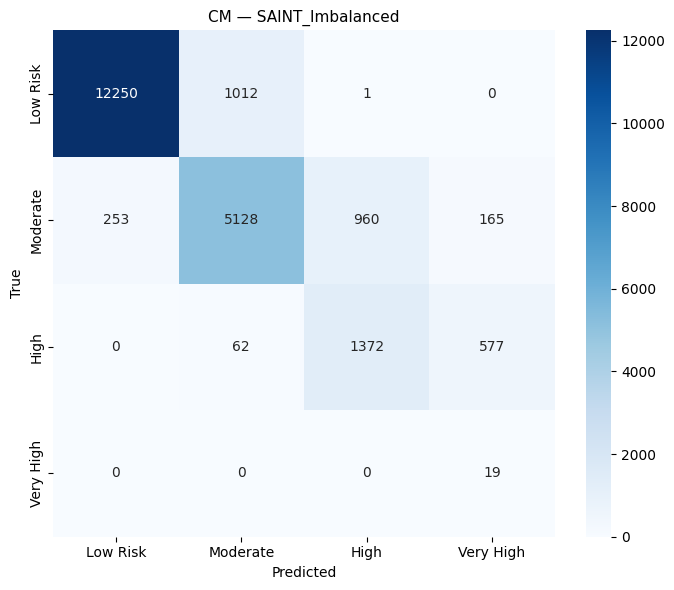


═══ Training XGBoost baseline (Balanced) ═══

──────────────────────────────────────────────────
Training XGBoost (Balanced)...

  XGBoost (Balanced) — Test
  Acc=0.9961  F1=0.9251  Kappa=0.9927  ROC=0.9999
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00     13263
    Moderate       0.99      1.00      0.99      6506
        High       0.99      0.99      0.99      2011
   Very High       0.70      0.74      0.72        19

    accuracy                           1.00     21799
   macro avg       0.92      0.93      0.93     21799
weighted avg       1.00      1.00      1.00     21799



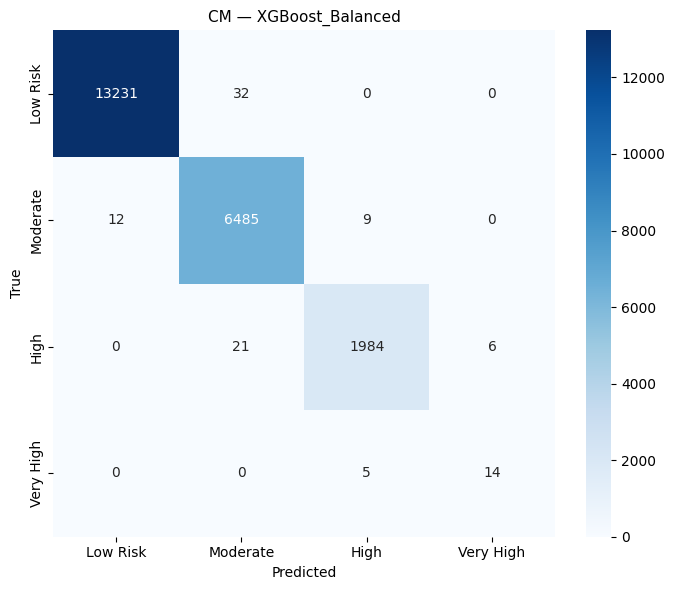


██████████████████████████████████████████████████████████████████████
  ★ PROPOSED: Stacked Ensemble (SAINT × XGBoost × RF → LR)
  ⚡ Optimized: 3-fold CV + compact SAINT (d=32, 4 heads, 2 layers)
██████████████████████████████████████████████████████████████████████
    ⏳ SAINTClassifier.fit() | samples=306509 | 11:47:30
    ✅ SAINTClassifier done | 12:03:02
    ⏳ SAINTClassifier.fit() | samples=204339 | 12:05:08
    ✅ SAINTClassifier done | 12:11:16
    ⏳ SAINTClassifier.fit() | samples=204339 | 12:11:30
    ✅ SAINTClassifier done | 12:17:58
    ⏳ SAINTClassifier.fit() | samples=204340 | 12:18:11
    ✅ SAINTClassifier done | 12:25:05


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed: 20.2min finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   42.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  3.3min finished



  SAINT-XGB-Stack (Balanced) — Test
  Acc=0.9907  F1=0.9401  Kappa=0.9826  ROC=0.9997
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00     13263
    Moderate       0.98      0.99      0.99      6506
        High       0.99      0.97      0.98      2011
   Very High       0.69      0.95      0.80        19

    accuracy                           0.99     21799
   macro avg       0.92      0.98      0.94     21799
weighted avg       0.99      0.99      0.99     21799

  Class                   TP       TN      FP      FN   Sensitivity   Specificity
  ----------------------------------------------------------------------------
  Low Risk             13198     8478      58      65        0.9951        0.9932
  Moderate              6431    15177     116      75        0.9885        0.9924
  High                  1950    19768      20      61        0.9697        0.9990
  Very High               18    21772       8       1        0.9474    

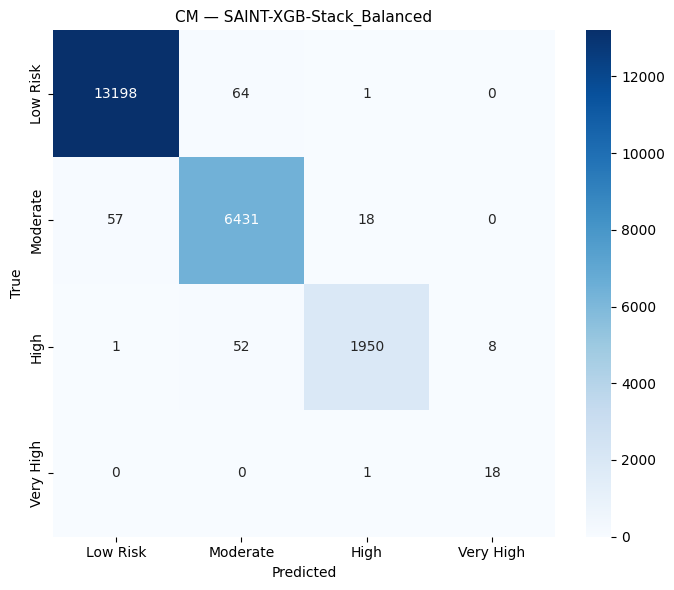


★ Proposed model complete! (41.9 min)


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — SAINT Baseline + ★ Stacked Ensemble (PROPOSED)                ║
# ║  OPTIMIZED: 3-fold CV + smaller SAINT (d=32, heads=4, layers=2) in stack  ║
# ║  Standalone SAINT uses full architecture (d=64, heads=8, layers=3)        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─── 1) SAINT Baseline ────────────────────────────────────────────────────────
print('\n═══ Training SAINT baseline (Balanced) ═══')
saint_bal, _ = train_dl(
    build_saint(n_features, n_classes, d_token=64, n_heads=8, n_layers=3, seed=SEED),
    'SAINT', X_tr_bal, y_tr_bal_idx,
    X_v_bal, y_val, X_te_bal, y_test,
    'Balanced', use_cw=True, patience=25
)

print('\n═══ Training SAINT baseline (Imbalanced) ═══')
saint_imb, _ = train_dl(
    build_saint(n_features, n_classes, d_token=64, n_heads=8, n_layers=3, seed=SEED),
    'SAINT', X_tr_imb, y_tr_imb_idx,
    X_v_imb, y_val, X_te_imb, y_test,
    'Imbalanced', use_cw=True, patience=25
)

# ─── 2) XGBoost Baseline ──────────────────────────────────────────────────────
print('\n═══ Training XGBoost baseline (Balanced) ═══')
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)
train_sklearn(xgb_model, 'XGBoost', X_tr_bal, y_train_bal,
              X_v_bal, y_val, X_te_bal, y_test, 'Balanced')

# ─── 3) ★ PROPOSED: Stacked Ensemble (SAINT + XGBoost + RF → LR) ─────────────
print('\n' + '█'*70)
print('  ★ PROPOSED: Stacked Ensemble (SAINT × XGBoost × RF → LR)')
print('  ⚡ Optimized: 3-fold CV + compact SAINT (d=32, 4 heads, 2 layers)')
print('█'*70)

from sklearn.base import BaseEstimator, ClassifierMixin

class SAINTClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_features=10, n_classes=4, d_token=32, n_heads=4,
                 n_layers=2, epochs=150, batch_size=256, lr=1e-3,
                 dropout=0.25, patience=15, seed=42):
        self.n_features = n_features
        self.n_classes = n_classes
        self.d_token = d_token
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.dropout = dropout
        self.patience = patience
        self.seed = seed
        self.model_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.sort(np.unique(y))
        y_idx = np.searchsorted(self.classes_, y)
        print(f'    ⏳ SAINTClassifier.fit() | samples={len(X)} | {time.strftime("%H:%M:%S")}')
        n_val = max(int(len(X) * 0.1), 100)
        indices = np.random.RandomState(self.seed).permutation(len(X))
        vi, ti = indices[:n_val], indices[n_val:]
        self.model_ = build_saint(
            self.n_features, self.n_classes,
            d_token=self.d_token, n_heads=self.n_heads,
            n_layers=self.n_layers, dropout=self.dropout, seed=self.seed
        )
        self.model_.fit(
            X[ti], y_idx[ti],
            validation_data=(X[vi], y_idx[vi]),
            epochs=self.epochs, batch_size=self.batch_size,
            class_weight=CW_DICT,
            callbacks=[
                callbacks.EarlyStopping(monitor='val_loss', patience=self.patience,
                                        restore_best_weights=True, verbose=0),
                callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                            patience=5, min_lr=1e-7, verbose=0),
            ],
            verbose=0
        )
        print(f'    ✅ SAINTClassifier done | {time.strftime("%H:%M:%S")}')
        return self

    def predict(self, X):
        proba = self.model_.predict(X, verbose=0)
        return self.classes_[proba.argmax(1)]

    def predict_proba(self, X):
        return self.model_.predict(X, verbose=0)

t0 = time.time()

stacking_model = StackingClassifier(
    estimators=[
        ('saint', SAINTClassifier(
            n_features=n_features, n_classes=n_classes,
            d_token=32, n_heads=4, n_layers=2,    # ← compact SAINT
            dropout=0.25, epochs=EPOCHS, batch_size=BATCH_SIZE,
            patience=15, seed=SEED
        )),
        ('xgboost', xgb.XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.7, colsample_bytree=0.7,
            reg_alpha=0.5, reg_lambda=2.0, min_child_weight=5,
            use_label_encoder=False, eval_metric='mlogloss',
            random_state=SEED, n_jobs=-1, verbosity=0
        )),
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=15, min_samples_leaf=5,
            random_state=SEED, n_jobs=-1
        )),
    ],
    final_estimator=LogisticRegression(
        max_iter=1000, random_state=SEED, multi_class='multinomial',
        class_weight='balanced', C=0.5
    ),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),  # ← 3-fold
    stack_method='predict_proba',
    passthrough=False, n_jobs=1, verbose=1
)

stacking_model.fit(X_tr_bal, y_train_bal)
tt_stack = time.time() - t0

y_tr_pred_stk  = stacking_model.predict(X_tr_bal)
y_v_pred_stk   = stacking_model.predict(X_v_bal)
y_te_pred_stk  = stacking_model.predict(X_te_bal)
y_v_proba_stk  = stacking_model.predict_proba(X_v_bal)
y_te_proba_stk = stacking_model.predict_proba(X_te_bal)

full_evaluate(
    'SAINT-XGB-Stack',
    y_train_bal, y_tr_pred_stk,
    y_val, y_v_pred_stk, y_v_proba_stk,
    y_test, y_te_pred_stk, y_te_proba_stk,
    tt_stack, 'Balanced', print_tptn=True
)
plot_confusion(y_test, y_te_pred_stk, 'SAINT-XGB-Stack_Balanced')

print(f'\n★ Proposed model complete! ({tt_stack/60:.1f} min)')


  TABLE 1A — TEST SET RESULTS | Santacruz (43003) | HI
          Model Training_Type  Accuracy  F1_macro  Precision  Recall  Kappa  ROC_AUC  Train_Time_s
SAINT-XGB-Stack      Balanced    0.9934    0.9470     0.9237  0.9781 0.9877   0.9998        3135.5
        XGBoost      Balanced    0.9961    0.9251     0.9210  0.9294 0.9927   0.9999          30.1
            SVC    Imbalanced    0.9703    0.8632     0.8429  0.8870 0.9447   0.9993         247.1
            KNN      Balanced    0.9381    0.7473     0.7273  0.8862 0.8839   0.9697           1.5
           BBAG    Imbalanced    0.9008    0.7234     0.7028  0.8592 0.8149   0.9830           1.2
       AdaBoost      Balanced    0.8562    0.7207     0.6931  0.8020 0.7416   0.8563          30.8
          SAINT      Balanced    0.8735    0.6734     0.6929  0.8744 0.7557   0.9231         679.7
            LDA      Balanced    0.7795    0.6492     0.6114  0.8236 0.6269   0.9591           0.3
     NaiveBayes    Imbalanced    0.7722    0.6168    

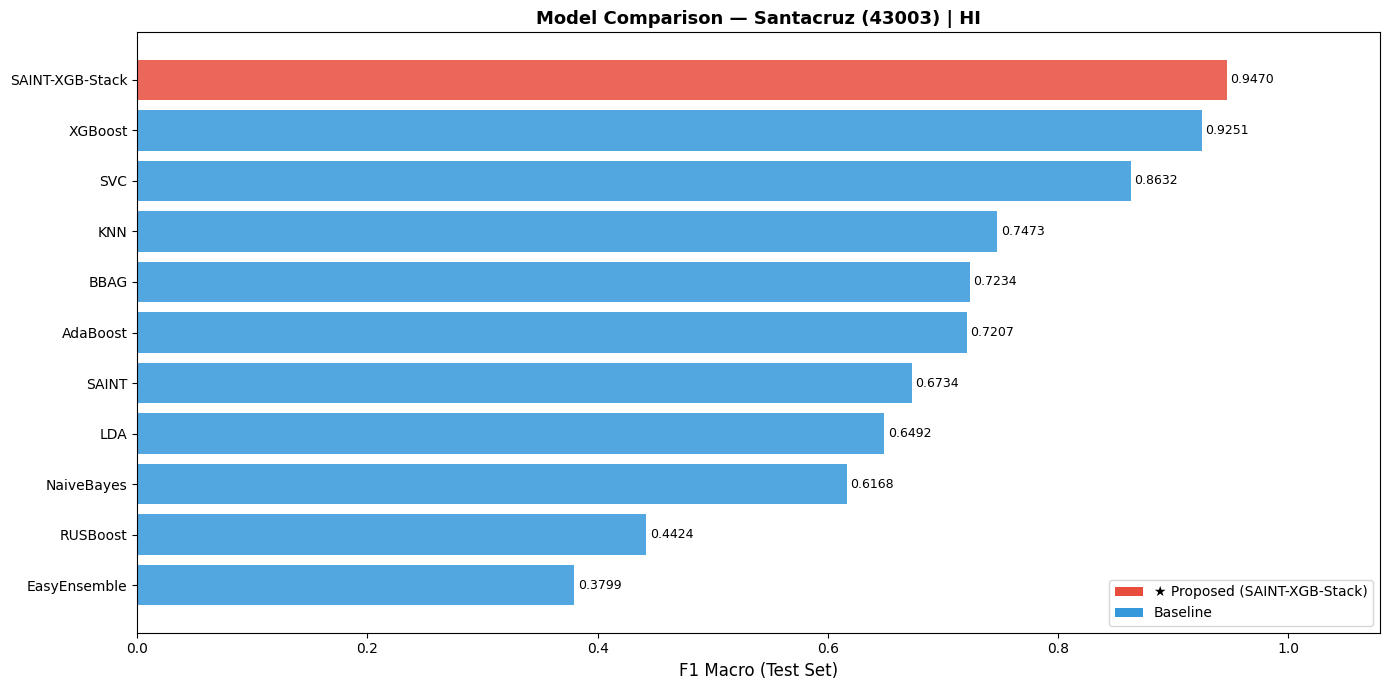

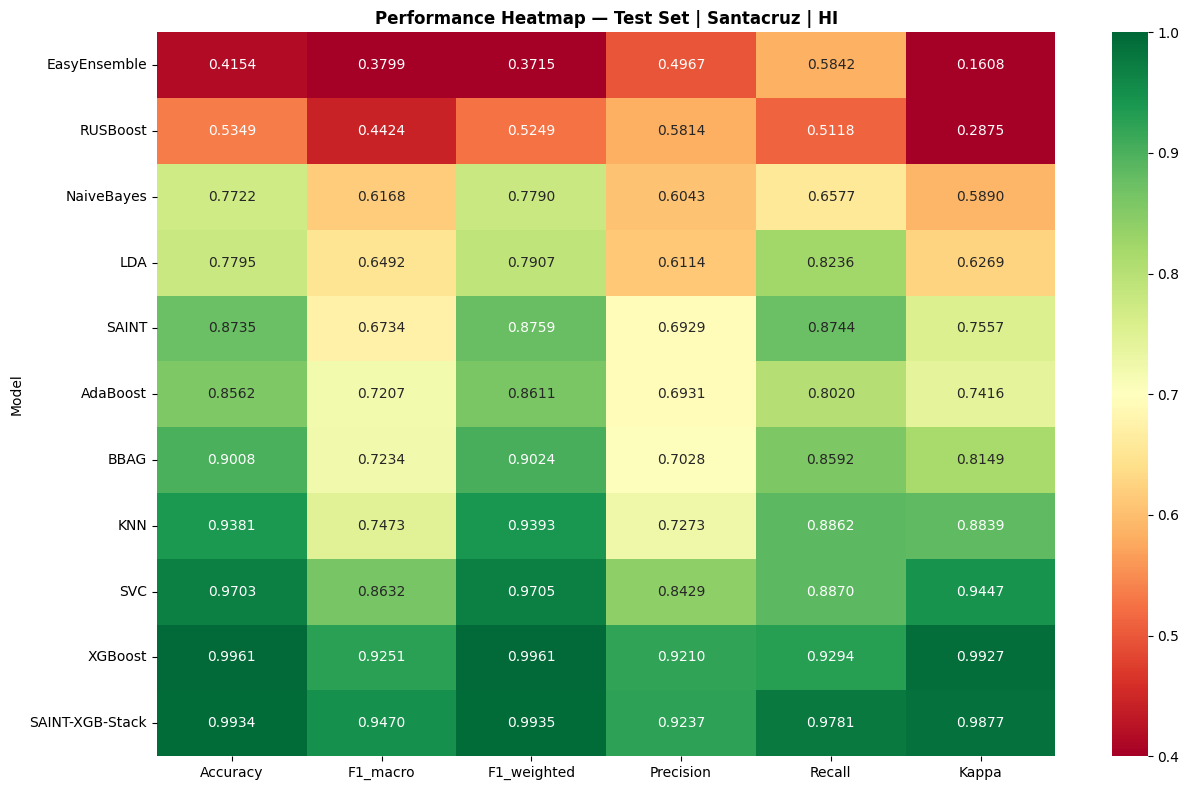

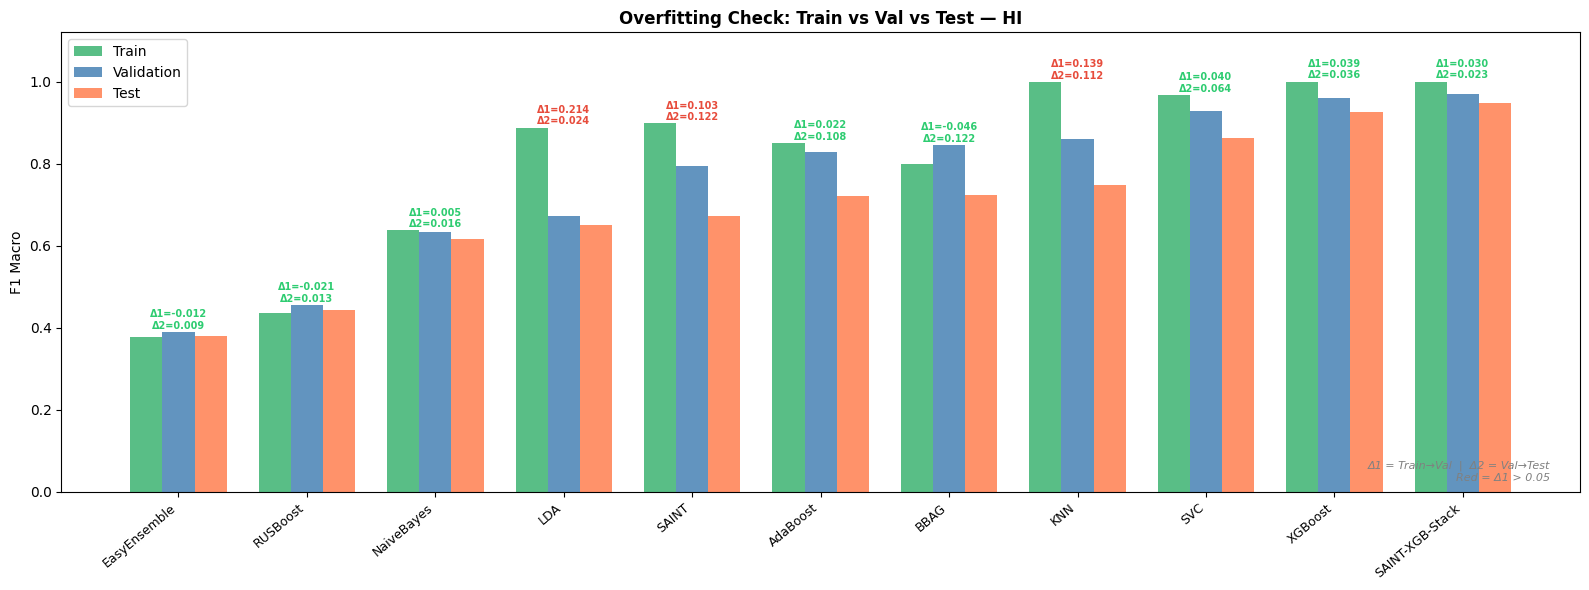

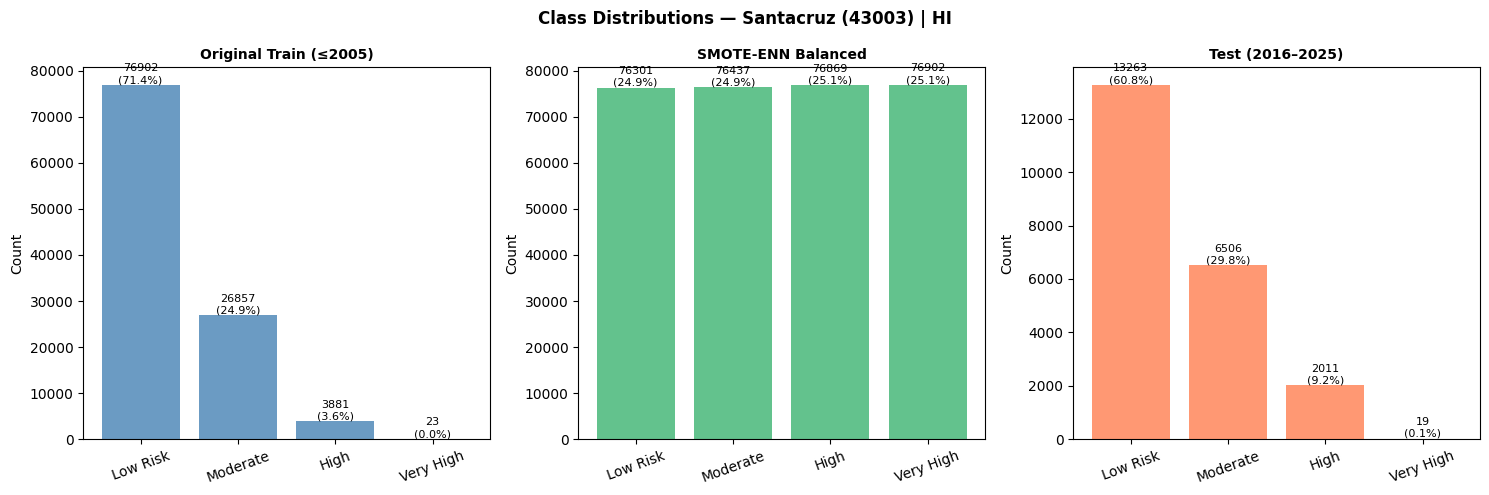

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  FINAL RESULTS — Tables + Plots + Overfitting + Validation
# ═══════════════════════════════════════════════════════════════════════════════
results_df     = pd.DataFrame(ALL_RESULTS)
results_df.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_ALL_results_nambiar.csv'),index=False)

test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro',ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro',ascending=False))

cols = ['Model','Training_Type','Accuracy','F1_macro','Precision','Recall','Kappa','ROC_AUC','Train_Time_s']

# TABLE 1A — TEST
print('\n' + '='*80)
print(f'  TABLE 1A — TEST SET RESULTS | {STATION} ({STATION_ID}) | {TARGET}')
print('='*80)
print(best_per_model[cols].to_string(index=False))
best_per_model[cols].to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table1a_best_test.csv'),index=False)

# TABLE 1B — VALIDATION
print('\n' + '='*80)
print(f'  TABLE 1B — VALIDATION SET RESULTS | {STATION} ({STATION_ID}) | {TARGET}')
print('='*80)
val_rows = []
for _, row in best_per_model.iterrows():
    m, bt = row['Model'], row['Training_Type']
    vr = results_df[(results_df['Model']==m) & (results_df['Split']=='Validation') & (results_df['Training_Type']==bt)]
    if len(vr): val_rows.append(vr.iloc[0])
val_df = pd.DataFrame(val_rows).sort_values('F1_macro', ascending=False)
print(val_df[cols].to_string(index=False))
val_df[cols].to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table1b_best_val.csv'),index=False)

# TABLE 1C — OVERFITTING
print('\n' + '='*80)
print(f'  TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON | {TARGET}')
print('='*80)
comparison_rows = []
for _, row in best_per_model.iterrows():
    m, bt = row['Model'], row['Training_Type']
    tr_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Train')      & (results_df['Training_Type']==bt)]
    val_r = results_df[(results_df['Model']==m) & (results_df['Split']=='Validation')  & (results_df['Training_Type']==bt)]
    te_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Test')        & (results_df['Training_Type']==bt)]
    tr_f1  = tr_r['F1_macro'].values[0]  if len(tr_r)  else np.nan
    val_f1 = val_r['F1_macro'].values[0] if len(val_r) else np.nan
    te_f1  = te_r['F1_macro'].values[0]  if len(te_r)  else np.nan
    comparison_rows.append({
        'Model': m, 'Training_Type': bt,
        'Train_F1': round(tr_f1,4), 'Val_F1': round(val_f1,4), 'Test_F1': round(te_f1,4),
        'Δ1_Train→Val': round(tr_f1-val_f1,4), 'Δ2_Val→Test': round(val_f1-te_f1,4),
    })
comp_df = pd.DataFrame(comparison_rows).sort_values('Test_F1', ascending=False)
print(comp_df.to_string(index=False))
comp_df.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table1c_overfit_analysis.csv'),index=False)

# TABLE 3 — COMPONENTS
print('\n' + '='*80)
print('  TABLE 3 — COMPONENT EVALUATION')
print('='*80)
comp_rows=[]
for m in ['SAINT','XGBoost','BBAG','SAINT-XGB-Stack']:
    r=results_df[(results_df['Model']==m)&(results_df['Split']=='Test')]
    if len(r):
        row=r.iloc[0]
        comp_rows.append({'Model':m,'Accuracy':row['Accuracy'],'F1_macro':row['F1_macro'],
                          'Recall':row['Recall'],'Precision':row['Precision'],
                          'Kappa':row['Kappa'],'ROC_AUC':row.get('ROC_AUC',np.nan)})
comp3=pd.DataFrame(comp_rows)
print(comp3.to_string(index=False))
comp3.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table3_component.csv'),index=False)
print(f'\n✅ All tables saved to {OUTPUT_DIR}')

# ═══════════════════════════════════════════════════════════════════════════════
#  PLOTS
# ═══════════════════════════════════════════════════════════════════════════════
best_plot = best_per_model.sort_values('F1_macro', ascending=True)

# PLOT 1: Model Ranking
fig,ax=plt.subplots(figsize=(14,7))
colors=['#e74c3c' if 'Stack' in m else '#3498db' for m in best_plot['Model']]
bars=ax.barh(best_plot['Model'],best_plot['F1_macro'],color=colors,alpha=0.85)
for bar,val in zip(bars,best_plot['F1_macro']):
    ax.text(val+0.003,bar.get_y()+bar.get_height()/2,f'{val:.4f}',va='center',fontsize=9)
ax.set_xlabel('F1 Macro (Test Set)',fontsize=12); ax.set_xlim(0,1.08)
ax.set_title(f'Model Comparison — {STATION} ({STATION_ID}) | {TARGET}',fontsize=13,fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c',label='★ Proposed (SAINT-XGB-Stack)'),
    Patch(facecolor='#3498db',label='Baseline')
],fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot1_ranking.png'),dpi=150,bbox_inches='tight')
plt.show()

# PLOT 2: Heatmap
fig,ax=plt.subplots(figsize=(13,8))
heat=best_plot.set_index('Model')[['Accuracy','F1_macro','F1_weighted','Precision','Recall','Kappa']]
sns.heatmap(heat.astype(float),annot=True,fmt='.4f',cmap='RdYlGn',vmin=0.4,vmax=1.0,ax=ax)
ax.set_title(f'Performance Heatmap — Test Set | {STATION} | {TARGET}',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot2_heatmap.png'),dpi=150,bbox_inches='tight')
plt.show()

# PLOT 3: Overfitting Check (3-bar)
fig, ax = plt.subplots(figsize=(16, 6))
mlist = best_plot['Model'].tolist()
tr_f1s, val_f1s, te_f1s = [], [], []
for m in mlist:
    bt = best_plot[best_plot['Model']==m]['Training_Type'].values[0]
    tr_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Train') & (results_df['Training_Type']==bt)]
    val_r = results_df[(results_df['Model']==m) & (results_df['Split']=='Validation') & (results_df['Training_Type']==bt)]
    te_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Test') & (results_df['Training_Type']==bt)]
    tr_f1s.append(tr_r['F1_macro'].values[0] if len(tr_r) else 0)
    val_f1s.append(val_r['F1_macro'].values[0] if len(val_r) else 0)
    te_f1s.append(te_r['F1_macro'].values[0] if len(te_r) else 0)
x = np.arange(len(mlist)); w = 0.25
ax.bar(x-w, tr_f1s, w, label='Train', color='mediumseagreen', alpha=0.85)
ax.bar(x,   val_f1s, w, label='Validation', color='steelblue', alpha=0.85)
ax.bar(x+w, te_f1s, w, label='Test', color='coral', alpha=0.85)
for i in range(len(mlist)):
    gap1 = tr_f1s[i] - val_f1s[i]; gap2 = val_f1s[i] - te_f1s[i]
    top = max(tr_f1s[i], val_f1s[i], te_f1s[i])
    color = '#e74c3c' if gap1 > 0.05 else '#2ecc71'
    ax.text(i, top+0.008, f'Δ1={gap1:.3f}\nΔ2={gap2:.3f}', ha='center', fontsize=7, color=color, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(mlist, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('F1 Macro'); ax.set_title(f'Overfitting Check: Train vs Val vs Test — {TARGET}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0, 1.12)
ax.text(0.98, 0.02, 'Δ1 = Train→Val  |  Δ2 = Val→Test\nRed = Δ1 > 0.05',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot3_overfit.png'),dpi=150,bbox_inches='tight')
plt.show()

# PLOT 4: Class Distribution
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,(data_arr,title,color) in zip(axes,[
    (y_train_raw,f'Original Train (≤{TRAIN_END})','steelblue'),
    (y_train_bal,'SMOTE-ENN Balanced','mediumseagreen'),
    (y_test,f'Test ({VAL_END+1}–2025)','coral')
]):
    counts=[np.sum(data_arr==c) for c in ALL_CLASSES]
    bars=ax.bar(CLASS_NAMES,counts,color=color,alpha=0.8)
    for bar,cnt in zip(bars,counts):
        pct=100*cnt/len(data_arr)
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{cnt}\n({pct:.1f}%)',ha='center',va='bottom',fontsize=8)
    ax.set_title(title,fontsize=10,fontweight='bold'); ax.set_ylabel('Count'); ax.tick_params(axis='x',rotation=20)
fig.suptitle(f'Class Distributions — {STATION} ({STATION_ID}) | {TARGET}',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot4_class_dist.png'),dpi=150,bbox_inches='tight')
plt.show()

In [ ]:
# FINAL SUMMARY
print('\n' + '='*70)
print(f'  ✅ ALL DONE — {STATION} ({STATION_ID}) | {TARGET}')
print(f'  Models : {len(set(results_df["Model"]))} | Results: {OUTPUT_DIR}')
print('='*70)
print('\nFinal ranking (Test F1 macro):')
for i,(_, row) in enumerate(best_per_model.iterrows(),1):
    tag = '★' if row['Model'] == 'SAINT-XGB-Stack' else ' '
    print(f'  {tag} {i:2d}. {row["Model"]:<22s}  F1={row["F1_macro"]:.4f}  Acc={row["Accuracy"]:.4f}  ({row["Training_Type"]})')

print()
print('  Test Performance (★ Proposed: SAINT-XGB-Stack):')
test_proposed = test_df[test_df['Model']=='SAINT-XGB-Stack'].iloc[0]
print(f'    Accuracy  : {test_proposed["Accuracy"]:.4f}')
print(f'    F1 macro  : {test_proposed["F1_macro"]:.4f}  ← proposed stacked ensemble')
print(f'    Kappa     : {test_proposed["Kappa"]:.4f}')
print(f'    ROC-AUC   : {test_proposed["ROC_AUC"]:.4f}')
print('='*70)


  ✅ ALL DONE — Santacruz (43003) | HI
  Models : 11 | Results: /content/drive/MyDrive/Major_project_imd/43003-HI-Model-final results

Final ranking (Test F1 macro):
  ★  1. SAINT-XGB-Stack         F1=0.9470  Acc=0.9934  (Balanced)
     2. XGBoost                 F1=0.9251  Acc=0.9961  (Balanced)
     3. SVC                     F1=0.8632  Acc=0.9703  (Imbalanced)
     4. KNN                     F1=0.7473  Acc=0.9381  (Balanced)
     5. BBAG                    F1=0.7234  Acc=0.9008  (Imbalanced)
     6. AdaBoost                F1=0.7207  Acc=0.8562  (Balanced)
     7. SAINT                   F1=0.6734  Acc=0.8735  (Balanced)
     8. LDA                     F1=0.6492  Acc=0.7795  (Balanced)
     9. NaiveBayes              F1=0.6168  Acc=0.7722  (Imbalanced)
    10. RUSBoost                F1=0.4424  Acc=0.5349  (Imbalanced)
    11. EasyEnsemble            F1=0.3799  Acc=0.4154  (Imbalanced)

  Test Performance (★ Proposed: SAINT-XGB-Stack):
    Accuracy  : 0.9934
    F1 macro  : 0.9470  

In [ ]:
# TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON
print('\n' + '='*80)
print(f'  TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON | {TARGET}')
print('='*80)
comparison_rows = []
for _, row in best_per_model.iterrows():
    m, bt = row['Model'], row['Training_Type']
    tr_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Train')      & (results_df['Training_Type']==bt)]
    val_r = results_df[(results_df['Model']==m) & (results_df['Split']=='Validation')  & (results_df['Training_Type']==bt)]
    te_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Test')        & (results_df['Training_Type']==bt)]
    tr_f1  = tr_r['F1_macro'].values[0]  if len(tr_r)  else np.nan
    val_f1 = val_r['F1_macro'].values[0] if len(val_r) else np.nan
    te_f1  = te_r['F1_macro'].values[0]  if len(te_r)  else np.nan
    comparison_rows.append({
        'Model': m, 'Training_Type': bt,
        'Train_F1': round(tr_f1,4), 'Val_F1': round(val_f1,4), 'Test_F1': round(te_f1,4),
        'Δ1_Train→Val': round(tr_f1-val_f1,4), 'Δ2_Val→Test': round(val_f1-te_f1,4),
    })
comp_df = pd.DataFrame(comparison_rows).sort_values('Test_F1', ascending=False)
print(comp_df.to_string(index=False))
comp_df.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table1c_overfit_analysis.csv'),index=False)


  TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON | HI
          Model Training_Type  Train_F1  Val_F1  Test_F1  Δ1_Train→Val  Δ2_Val→Test
SAINT-XGB-Stack      Balanced    0.9995  0.9700   0.9470        0.0295       0.0230
        XGBoost      Balanced    1.0000  0.9609   0.9251        0.0391       0.0358
            SVC    Imbalanced    0.9669  0.9272   0.8632        0.0397       0.0640
            KNN      Balanced    0.9981  0.8594   0.7473        0.1387       0.1121
           BBAG    Imbalanced    0.7992  0.8450   0.7234       -0.0458       0.1216
       AdaBoost      Balanced    0.8506  0.8283   0.7207        0.0223       0.1076
          SAINT      Balanced    0.8978  0.7951   0.6734        0.1027       0.1217
            LDA      Balanced    0.8874  0.6734   0.6492        0.2140       0.0242
     NaiveBayes    Imbalanced    0.6371  0.6325   0.6168        0.0046       0.0157
       RUSBoost    Imbalanced    0.4346  0.4555   0.4424       -0.0209       0.0131
   EasyEnsemble    Imb

In [ ]:
# TABLE 1A — TEST SET RESULTS (already exists, kept for reference)
print("\n" + "═"*80)
print(f"  TABLE 1A — TEST SET RESULTS (Best per model) | {STATION} ({STATION_ID}) | {TARGET}")
print("═"*80)
cols = ['Model','Training_Type','Accuracy','F1_macro','Precision','Recall','Kappa','ROC_AUC','Train_Time_s']
print(best_per_model[cols].to_string(index=False))
best_per_model[cols].to_csv(
    os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_table1a_best_test.csv'), index=False)

# TABLE 1B — VALIDATION SET RESULTS (matching best training type from test)
print("\n" + "═"*80)
print(f"  TABLE 1B — VALIDATION SET RESULTS (same training type as best test) | {STATION} ({STATION_ID}) | {TARGET}")
print("═"*80)

val_rows = []
for _, row in best_per_model.iterrows():
    m, bt = row['Model'], row['Training_Type']
    vr = results_df[(results_df['Model']==m) &
                     (results_df['Split']=='Validation') &
                     (results_df['Training_Type']==bt)]
    if len(vr):
        val_rows.append(vr.iloc[0])

val_df = pd.DataFrame(val_rows).sort_values('F1_macro', ascending=False)
print(val_df[cols].to_string(index=False))
val_df[cols].to_csv(
    os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_table1b_best_val.csv'), index=False)

# TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON
print('\n' + '='*80)
print(f'  TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON | {TARGET}')
print('='*80)
comparison_rows = []
for _, row in best_per_model.iterrows():
    m, bt = row['Model'], row['Training_Type']
    tr_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Train')      & (results_df['Training_Type']==bt)]
    val_r = results_df[(results_df['Model']==m) & (results_df['Split']=='Validation')  & (results_df['Training_Type']==bt)]
    te_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Test')        & (results_df['Training_Type']==bt)]
    tr_f1  = tr_r['F1_macro'].values[0]  if len(tr_r)  else np.nan
    val_f1 = val_r['F1_macro'].values[0] if len(val_r) else np.nan
    te_f1  = te_r['F1_macro'].values[0]  if len(te_r)  else np.nan
    comparison_rows.append({
        'Model': m, 'Training_Type': bt,
        'Train_F1': round(tr_f1,4), 'Val_F1': round(val_f1,4), 'Test_F1': round(te_f1,4),
        'Δ1_Train→Val': round(tr_f1-val_f1,4), 'Δ2_Val→Test': round(val_f1-te_f1,4),
    })
comp_df = pd.DataFrame(comparison_rows).sort_values('Test_F1', ascending=False)
print(comp_df.to_string(index=False))
comp_df.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table1c_overfit_analysis.csv'),index=False)



print(f"\n✅ Tables 1A, 1B. 1C saved to {OUTPUT_DIR}")


════════════════════════════════════════════════════════════════════════════════
  TABLE 1A — TEST SET RESULTS (Best per model) | Santacruz (43003) | HI
════════════════════════════════════════════════════════════════════════════════
          Model Training_Type  Accuracy  F1_macro  Precision  Recall  Kappa  ROC_AUC  Train_Time_s
SAINT-XGB-Stack      Balanced    0.9934    0.9470     0.9237  0.9781 0.9877   0.9998        3135.5
        XGBoost      Balanced    0.9961    0.9251     0.9210  0.9294 0.9927   0.9999          30.1
            SVC    Imbalanced    0.9703    0.8632     0.8429  0.8870 0.9447   0.9993         247.1
            KNN      Balanced    0.9381    0.7473     0.7273  0.8862 0.8839   0.9697           1.5
           BBAG    Imbalanced    0.9008    0.7234     0.7028  0.8592 0.8149   0.9830           1.2
       AdaBoost      Balanced    0.8562    0.7207     0.6931  0.8020 0.7416   0.8563          30.8
          SAINT      Balanced    0.8735    0.6734     0.6929  0.8744 0.7

In [14]:
################################################################################
#  MODEL DEPLOYMENT — SAINT-XGB-Stack
#
#  CELL A: Save model artifacts (run ONCE per station after training)
#          Run in 43003 notebook → saves 43003 artifacts
#          Run in 43057 notebook → saves 43057 artifacts
#
#  CELL C: ★ QUICK LOAD BOTH STATIONS — Single API, one ngrok URL
#          Loads both 43003 + 43057 from Drive
#          One URL serves both stations
################################################################################


# ══════════════════════════════════════════════════════════════════════════════
# CELL A — SAVE MODEL ARTIFACTS (updated — saves weights instead of full model)
# ══════════════════════════════════════════════════════════════════════════════

import joblib, json, os
import numpy as np

DEPLOY_DIR = os.path.join(OUTPUT_DIR, 'deployment')
os.makedirs(DEPLOY_DIR, exist_ok=True)

print(f'Saving model artifacts for {STATION} ({STATION_ID})...\n')

joblib.dump(scaler_bal, os.path.join(DEPLOY_DIR, f'{STATION_ID}_scaler.joblib'))
print(f'  ✅ Scaler saved')

fitted_estimators = stacking_model.estimators_

saint_clf = fitted_estimators[0]
saint_clf.model_.save_weights(os.path.join(DEPLOY_DIR, f'{STATION_ID}_saint.weights.h5'))
np.save(os.path.join(DEPLOY_DIR, f'{STATION_ID}_saint_classes.npy'), saint_clf.classes_)
print(f'  ✅ SAINT weights saved')

xgb_clf = fitted_estimators[1]
xgb_clf.save_model(os.path.join(DEPLOY_DIR, f'{STATION_ID}_xgboost.json'))
print(f'  ✅ XGBoost saved')

rf_clf = fitted_estimators[2]
joblib.dump(rf_clf, os.path.join(DEPLOY_DIR, f'{STATION_ID}_rf.joblib'))
print(f'  ✅ RF saved')

meta_lr = stacking_model.final_estimator_
joblib.dump(meta_lr, os.path.join(DEPLOY_DIR, f'{STATION_ID}_meta_lr.joblib'))
print(f'  ✅ Meta-learner saved')

config = {
    'station_id': STATION_ID, 'station_name': STATION, 'target': TARGET,
    'features': FEATURES, 'class_names': CLASS_NAMES,
    'n_classes': n_classes, 'n_features': n_features,
    'all_classes': ALL_CLASSES.tolist(),
}
with open(os.path.join(DEPLOY_DIR, f'{STATION_ID}_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print(f'  ✅ Config saved')

print(f'\n{"═"*50}')
print(f'📁 All artifacts saved to: {DEPLOY_DIR}')
for fname in sorted(os.listdir(DEPLOY_DIR)):
    sz = os.path.getsize(os.path.join(DEPLOY_DIR, fname)) / 1024
    print(f'  📄 {fname:40s} ({sz:>8.1f} KB)')
print(f'{"═"*50}')


Saving model artifacts for Santacruz (43003)...

  ✅ Scaler saved
  ✅ SAINT weights saved
  ✅ XGBoost saved
  ✅ RF saved
  ✅ Meta-learner saved
  ✅ Config saved

══════════════════════════════════════════════════
📁 All artifacts saved to: /content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43003-HI-Model-final results/deployment
  📄 43003_config.json                        (     0.4 KB)
  📄 43003_meta_lr.joblib                     (     1.3 KB)
  📄 43003_rf.joblib                          ( 22597.6 KB)
  📄 43003_saint.keras                        (   701.1 KB)
  📄 43003_saint.weights.h5                   (   669.7 KB)
  📄 43003_saint_classes.npy                  (     0.2 KB)
  📄 43003_scaler.joblib                      (     0.8 KB)
  📄 43003_xgboost.json                       (  2056.5 KB)
══════════════════════════════════════════════════


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# ★ CELL C — QUICK LOAD BOTH STATIONS (STANDALONE)
# ══════════════════════════════════════════════════════════════════════════════

STATION_CONFIGS = {
    '43003': {
        'deploy_dir': '/content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43003-HI-Model-final results/deployment',
        'name': 'Santacruz',
    },
    '43057': {
        'deploy_dir': '/content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43057-HI-Model-final results/deployment',
        'name': 'Colaba',
    },
}

NGROK_TOKEN = '3CODVwgu9mgvPjag6iQhEMMl9Jg_6HT9Bo3MotGE6LH5yvuZp'

# ══════════════════════════════════════════════════════════════════
# STEP 1: Mount Drive + Install packages
# ══════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

!pip install flask flask-cors pyngrok xgboost --quiet

import os, json, time, threading
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model, callbacks
import xgboost as xgb_lib

for sid, scfg in STATION_CONFIGS.items():
    assert os.path.exists(scfg['deploy_dir']), \
        f"❌ Deploy folder for {sid} ({scfg['name']}) not found at:\n   {scfg['deploy_dir']}\n   Did you run Cell A in the {sid} notebook?"
    print(f'📂 Found {sid} ({scfg["name"]}) artifacts at: {scfg["deploy_dir"]}')

# ══════════════════════════════════════════════════════════════════
# STEP 2: SAINT architecture + builder
# ══════════════════════════════════════════════════════════════════
LR = 1e-3

class IntersampleAttentionLayer(layers.Layer):
    def __init__(self, n_heads, d_model, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.n_heads = n_heads
        self.d_model = d_model
        self.dropout_rate = dropout
        self.mha = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.drop = layers.Dropout(dropout)

    def call(self, x, training=None):
        xt = tf.transpose(x, perm=[1, 0, 2])
        attn_out = self.mha(xt, xt, training=training)
        attn_out = self.drop(attn_out, training=training)
        xt = self.norm(xt + attn_out)
        return tf.transpose(xt, perm=[1, 0, 2])

    def get_config(self):
        config = super().get_config()
        config.update({'n_heads': self.n_heads, 'd_model': self.d_model, 'dropout': self.dropout_rate})
        return config

class SAINTEncoderBlock(layers.Layer):
    def __init__(self, n_heads, d_model, ffn_mult=4, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.n_heads = n_heads
        self.d_model = d_model
        self.ffn_mult = ffn_mult
        self.dropout_rate = dropout
        self.col_norm = layers.LayerNormalization(epsilon=1e-6)
        self.col_mha  = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.col_drop = layers.Dropout(dropout)
        self.row_attn = IntersampleAttentionLayer(n_heads, d_model, dropout)
        self.ffn_norm = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = keras.Sequential([
            layers.Dense(d_model*ffn_mult, activation='gelu', kernel_regularizer=regularizers.l2(1e-5)),
            layers.Dropout(dropout),
            layers.Dense(d_model, kernel_regularizer=regularizers.l2(1e-5)),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=None):
        x_norm = self.col_norm(x)
        attn = self.col_mha(x_norm, x_norm, training=training)
        attn = self.col_drop(attn, training=training)
        x = x + attn
        x = self.row_attn(x, training=training)
        x_norm = self.ffn_norm(x)
        x = x + self.ffn(x_norm, training=training)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({'n_heads': self.n_heads, 'd_model': self.d_model, 'ffn_mult': self.ffn_mult, 'dropout': self.dropout_rate})
        return config

def build_saint_deploy(n_features, n_classes, d_token=32, n_heads=4, n_layers=2, dropout=0.25):
    """Rebuild the exact SAINT architecture used in training (compact stack version)."""
    tf.random.set_seed(42)
    inp = layers.Input(shape=(n_features,), name='input')
    token_list = []
    for j in range(n_features):
        f_j = layers.Lambda(lambda x, i=j: x[:, i:i+1])(inp)
        t_j = layers.Dense(d_token, use_bias=True, kernel_regularizer=regularizers.l2(1e-5))(f_j)
        token_list.append(layers.Reshape((1, d_token))(t_j))
    feature_tokens = layers.Concatenate(axis=1)(token_list)
    cls_token = tf.Variable(tf.zeros((1, 1, d_token)), trainable=True, name='cls_token')
    cls_tiled = layers.Lambda(lambda x: tf.tile(cls_token, [tf.shape(x)[0], 1, 1]))(feature_tokens)
    tokens = layers.Concatenate(axis=1)([cls_tiled, feature_tokens])
    x = tokens
    for li in range(n_layers):
        x = SAINTEncoderBlock(n_heads=n_heads, d_model=d_token, ffn_mult=4,
                              dropout=dropout, name=f'saint_block_{li}')(x)
    cls_out = layers.Lambda(lambda x: x[:, 0, :])(x)
    cls_out = layers.LayerNormalization(epsilon=1e-6)(cls_out)
    logits = layers.Dense(n_classes, activation='softmax', dtype='float32', name='output')(cls_out)
    m = Model(inp, logits, name='SAINT')
    m.compile(optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

print('✅ SAINT architecture + builder defined')

# ══════════════════════════════════════════════════════════════════
# STEP 3: Load BOTH stations' models
# ══════════════════════════════════════════════════════════════════
MODELS = {}

for station_id, scfg in STATION_CONFIGS.items():
    ddir = scfg['deploy_dir']
    print(f'\n{"─"*40}')
    print(f'Loading {station_id} ({scfg["name"]})...')

    with open(os.path.join(ddir, f'{station_id}_config.json')) as f:
        cfg = json.load(f)

    scaler = joblib.load(os.path.join(ddir, f'{station_id}_scaler.joblib'))
    print(f'  ✅ Scaler loaded')

    # SAINT — rebuild architecture then load weights
    saint = build_saint_deploy(cfg['n_features'], cfg['n_classes'])
    saint.load_weights(os.path.join(ddir, f'{station_id}_saint.weights.h5'))
    saint_classes = np.load(os.path.join(ddir, f'{station_id}_saint_classes.npy'))
    print(f'  ✅ SAINT rebuilt + weights loaded')

    xgb_model = xgb_lib.XGBClassifier()
    xgb_model.load_model(os.path.join(ddir, f'{station_id}_xgboost.json'))
    print(f'  ✅ XGBoost loaded')

    rf_model = joblib.load(os.path.join(ddir, f'{station_id}_rf.joblib'))
    print(f'  ✅ RF loaded')

    meta_model = joblib.load(os.path.join(ddir, f'{station_id}_meta_lr.joblib'))
    print(f'  ✅ Meta-learner loaded')

    MODELS[station_id] = {
        'cfg': cfg, 'scaler': scaler, 'saint': saint,
        'saint_classes': saint_classes, 'xgb': xgb_model,
        'rf': rf_model, 'meta': meta_model,
    }
    print(f'  ✅ {scfg["name"]} ({station_id}) — all models ready!')

print(f'\n{"═"*50}')
print(f'✅ BOTH stations loaded successfully!')
print(f'   43003 (Santacruz) — ready')
print(f'   43057 (Colaba)    — ready')
print(f'{"═"*50}')

# ══════════════════════════════════════════════════════════════════
# STEP 4: Prediction functions
# ══════════════════════════════════════════════════════════════════
def compute_all_features(dbt, rh, fff=10.0, month=4, hour_code=36):
    gamma = np.log(rh / 100) + (17.67 * dbt) / (243.5 + dbt)
    dpt = (243.5 * gamma) / (17.67 - gamma)
    wbt = dbt * np.arctan(0.151977 * (rh + 8.313659)**0.5) \
        + np.arctan(dbt + rh) - np.arctan(rh - 1.676331) \
        + 0.00391838 * rh**1.5 * np.arctan(0.023101 * rh) - 4.686035
    vp = 6.112 * np.exp((17.67 * dpt) / (dpt + 243.5))
    svp = 6.112 * np.exp((17.67 * dbt) / (dbt + 243.5))
    vpd = max(svp - vp, 0)
    return {
        'DBT': dbt, 'WBT': round(wbt, 2), 'VPD': round(vpd, 2),
        'VP': round(vp, 2), 'DPT': round(dpt, 2),
        'Temp_RH': round(dbt * rh / 100, 2), 'FFF': fff,
        'Month_cos': round(np.cos(2 * np.pi * month / 12), 4),
        'Hour_cos': round(np.cos(2 * np.pi * hour_code / 84), 4),
        'WBD': round(dbt - wbt, 2),
    }

def predict_hi(station_id, features_dict):
    if station_id not in MODELS:
        return {'error': f'Station {station_id} not loaded. Available: {list(MODELS.keys())}'}
    m = MODELS[station_id]
    cfg = m['cfg']
    x = np.array([[features_dict[f] for f in cfg['features']]])
    x_scaled = m['scaler'].transform(x)
    saint_proba = m['saint'].predict(x_scaled, verbose=0)
    xgb_proba   = m['xgb'].predict_proba(x_scaled)
    rf_proba    = m['rf'].predict_proba(x_scaled)
    meta_input = np.hstack([saint_proba, xgb_proba, rf_proba])
    pred_class = int(m['meta'].predict(meta_input)[0])
    pred_proba = m['meta'].predict_proba(meta_input)[0]
    dbt = features_dict['DBT']
    rh = features_dict['Temp_RH'] / dbt * 100 if dbt > 0 else 70
    tf_val = dbt * 9/5 + 32
    hi = -42.379 + 2.04901523*tf_val + 10.14333127*rh \
         - 0.22475541*tf_val*rh - 6.83783e-3*tf_val**2 \
         - 5.481717e-2*rh**2 + 1.22874e-3*tf_val**2*rh \
         + 8.5282e-4*tf_val*rh**2 - 1.99e-6*tf_val**2*rh**2
    if rh > 85 and 80 <= tf_val <= 87:
        hi += ((rh-85)/10) * ((87-tf_val)/5)
    if rh < 13 and 80 <= tf_val <= 112:
        hi -= ((13-rh)/4) * np.sqrt((17-abs(tf_val-95))/17)
    avg = 0.5*(0.5*(tf_val+61+(tf_val-68)*1.2+rh*0.094)+tf_val)
    if avg < 80:
        hi = 0.5*(tf_val+61+(tf_val-68)*1.2+rh*0.094)
    hi_c = round((hi-32)*5/9, 1)
    return {
        'predicted_class': pred_class,
        'class_name': cfg['class_names'][pred_class],
        'hi_value': hi_c,
        'probabilities': {cfg['class_names'][i]: round(float(pred_proba[i]), 4) for i in range(cfg['n_classes'])},
        'base_models': {
            'SAINT': [round(float(p), 4) for p in saint_proba[0]],
            'XGBoost': [round(float(p), 4) for p in xgb_proba[0]],
            'RF': [round(float(p), 4) for p in rf_proba[0]],
        },
        'station': cfg['station_name'], 'station_id': cfg['station_id'],
    }

# ── Self-test ───────────────────────────────────────────────────
print('\n🧪 Self-test predictions:')
test_cases = [(38.5, 85, "Hot+Humid"), (28.0, 60, "Mild"), (42.0, 75, "Extreme"), (25.0, 50, "Cool+Dry")]
for sid in ['43003', '43057']:
    print(f'\n  {sid} ({STATION_CONFIGS[sid]["name"]}):')
    for dbt, rh, desc in test_cases:
        feats = compute_all_features(dbt, rh, fff=8, month=5, hour_code=36)
        res = predict_hi(sid, feats)
        print(f'    {desc:12s} DBT={dbt}°C RH={rh}% → HI={res["hi_value"]}°C → {res["class_name"]}')

# ══════════════════════════════════════════════════════════════════
# STEP 5: Flask API
# ══════════════════════════════════════════════════════════════════
from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)
CORS(app)

@app.route('/predict/hi', methods=['POST'])
def predict_endpoint():
    try:
        data = request.json
        station_id = str(data.get('station', '43003'))
        if station_id not in MODELS:
            return jsonify({'error': f'Unknown station: {station_id}. Use 43003 or 43057'}), 400
        cfg = MODELS[station_id]['cfg']
        if all(f in data for f in cfg['features']):
            features = {f: float(data[f]) for f in cfg['features']}
        else:
            features = compute_all_features(
                dbt=float(data['DBT']), rh=float(data.get('RH', 70)),
                fff=float(data.get('FFF', 10)), month=int(data.get('Month', 4)),
                hour_code=int(data.get('Hour', 36)))
        result = predict_hi(station_id, features)
        result['input_features'] = features
        return jsonify(result)
    except Exception as e:
        import traceback
        return jsonify({'error': str(e), 'trace': traceback.format_exc()}), 400

@app.route('/info', methods=['GET'])
def info():
    return jsonify({
        'stations': {sid: {'name': m['cfg']['station_name'], 'features': m['cfg']['features'],
                           'classes': m['cfg']['class_names']} for sid, m in MODELS.items()},
        'model': 'SAINT-XGB-Stack', 'status': 'ready', 'stations_loaded': list(MODELS.keys())})

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'stations': list(MODELS.keys())})

# ══════════════════════════════════════════════════════════════════
# STEP 6: Start ngrok
# ══════════════════════════════════════════════════════════════════
from pyngrok import ngrok
if NGROK_TOKEN:
    ngrok.set_auth_token(NGROK_TOKEN)

port = 5000
public_url = ngrok.connect(port)

print(f'\n{"═"*65}')
print(f'  🚀 SAINT-XGB-Stack API — BOTH STATIONS')
print(f'{"═"*65}')
print(f'  🌐 Public URL: {public_url}')
print(f'')
print(f'  Stations: 43003 (Santacruz) + 43057 (Colaba)')
print(f'')
print(f'  POST {public_url}/predict/hi')
print(f'    Santacruz: {{"station":"43003", "DBT":38.5, "RH":85}}')
print(f'    Colaba:    {{"station":"43057", "DBT":38.5, "RH":85}}')
print(f'')
print(f'  ⚡ Paste URL into React dashboard!')
print(f'{"═"*65}')

threading.Thread(target=lambda: app.run(port=port, use_reloader=False)).start()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Found 43003 (Santacruz) artifacts at: /content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43003-HI-Model-final results/deployment
📂 Found 43057 (Colaba) artifacts at: /content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43057-HI-Model-final results/deployment
✅ SAINT architecture + builder defined

────────────────────────────────────────
Loading 43003 (Santacruz)...
  ✅ Scaler loaded
  ✅ SAINT rebuilt + weights loaded
  ✅ XGBoost loaded
  ✅ RF loaded
  ✅ Meta-learner loaded
  ✅ Santacruz (43003) — all models ready!

────────────────────────────────────────
Loading 43057 (Colaba)...
  ✅ Scaler loaded


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43057-HI-Model-final results/deployment/43057_saint.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)